In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# load file
# =========================
file_path = "training_results_history.xlsx"
df = pd.read_excel(file_path)

# =========================
# clean data
# =========================
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

numeric_cols = ["epoch", "loss", "precision", "recall", "f1", "iou"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# remove exact duplicate rows
df = df.drop_duplicates()

# sort by time so plots follow experiment order
df = df.sort_values("timestamp").reset_index(drop=True)

# shorter label for plotting
df["label"] = [f"{i+1}. {name}" for i, name in enumerate(df["run_name"])]

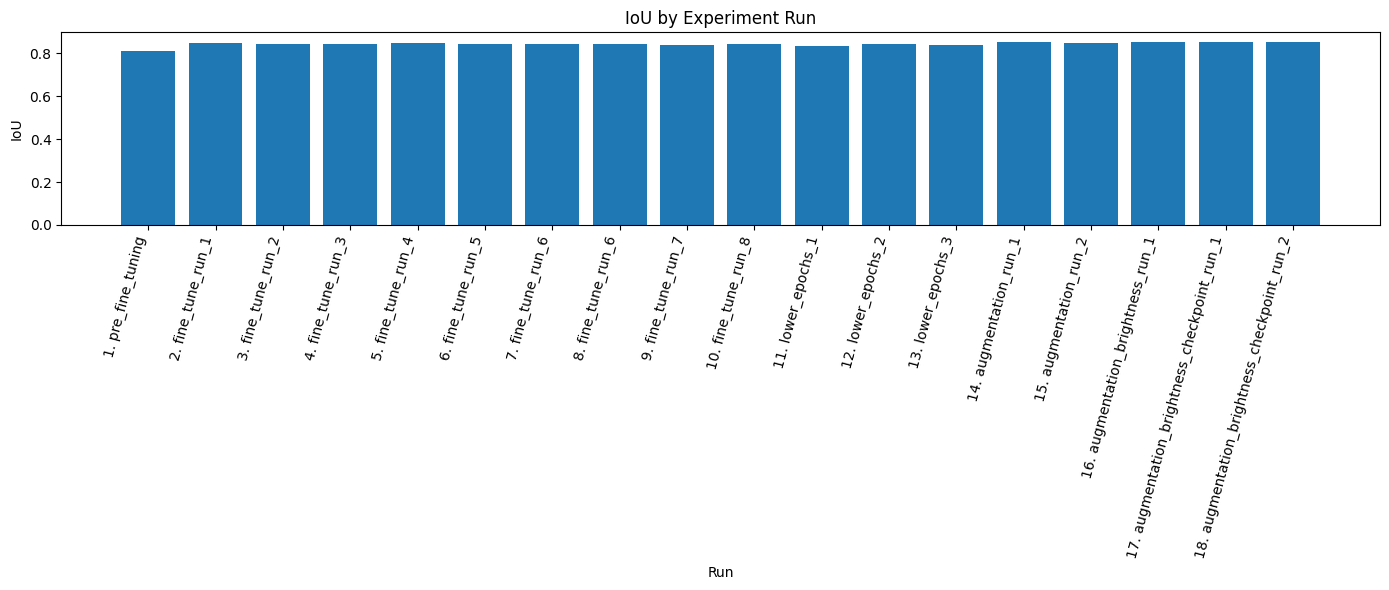

In [2]:
plt.figure(figsize=(14, 6))
plt.bar(df["label"], df["iou"])
plt.xticks(rotation=75, ha="right")
plt.ylabel("IoU")
plt.xlabel("Run")
plt.title("IoU by Experiment Run")
plt.tight_layout()
plt.show()

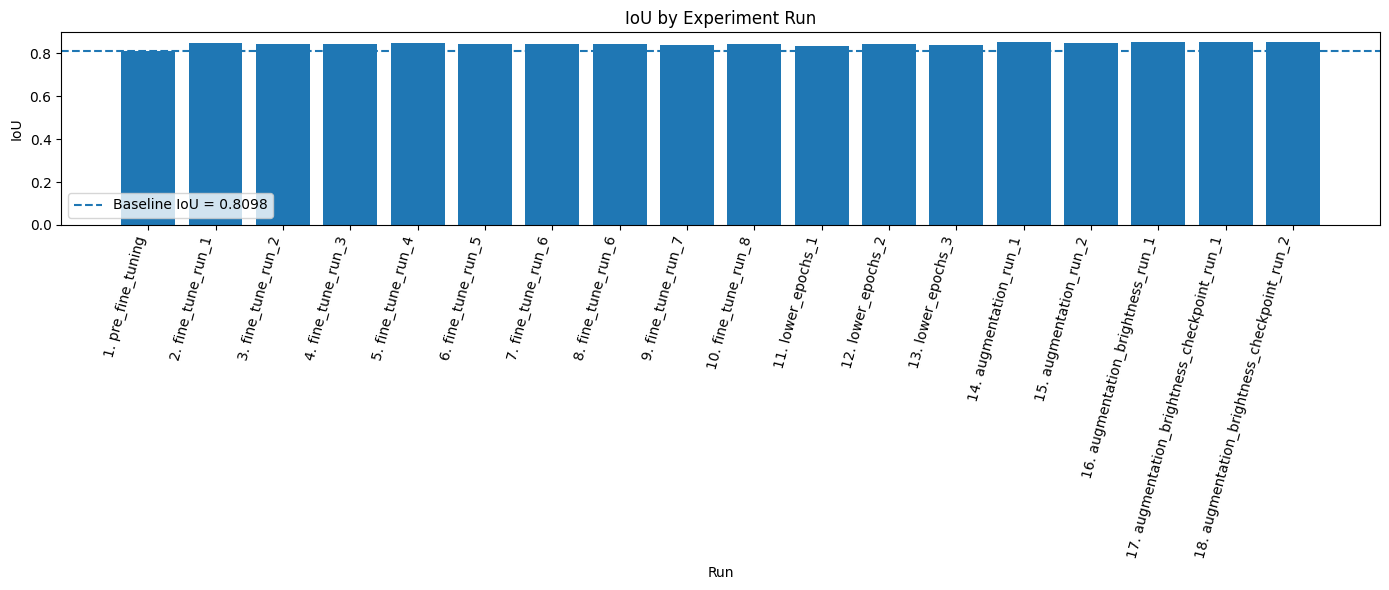

In [3]:
baseline_iou = df.loc[df["run_name"] == "pre_fine_tuning", "iou"].iloc[0]

plt.figure(figsize=(14, 6))
plt.bar(df["label"], df["iou"])
plt.axhline(baseline_iou, linestyle="--", label=f"Baseline IoU = {baseline_iou:.4f}")
plt.xticks(rotation=75, ha="right")
plt.ylabel("IoU")
plt.xlabel("Run")
plt.title("IoU by Experiment Run")
plt.legend()
plt.tight_layout()
plt.show()

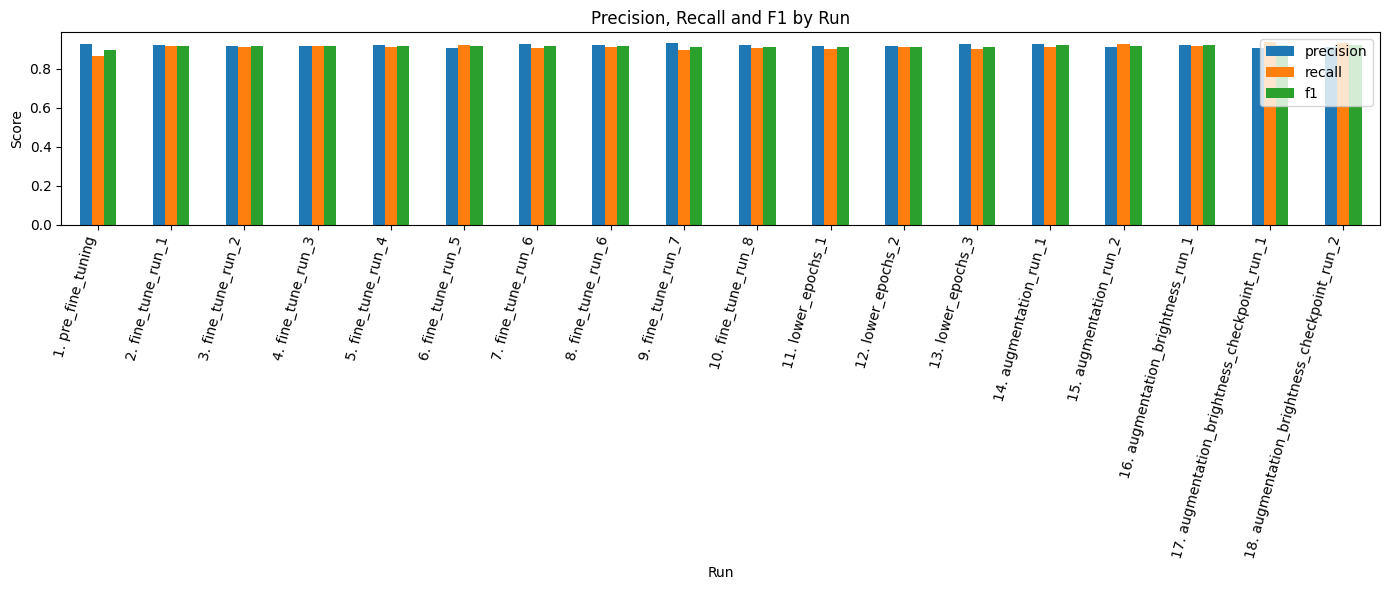

In [4]:
metrics_df = df[["label", "precision", "recall", "f1"]].set_index("label")

metrics_df.plot(kind="bar", figsize=(14, 6))
plt.ylabel("Score")
plt.xlabel("Run")
plt.title("Precision, Recall and F1 by Run")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

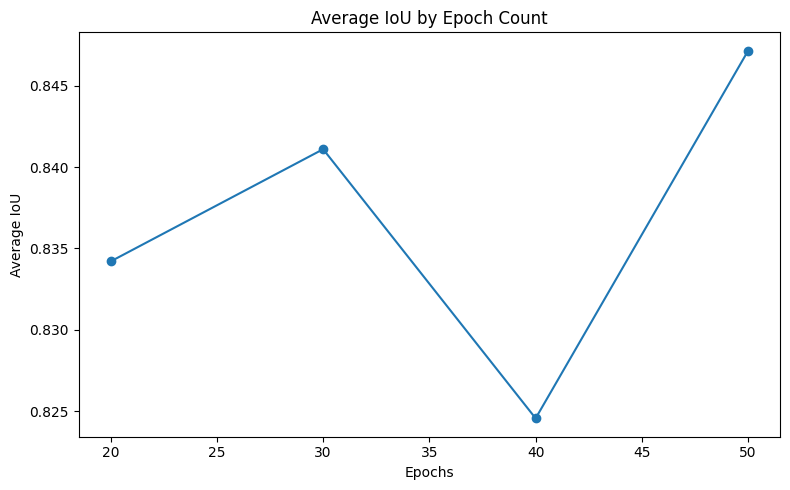

In [5]:
epoch_summary = df.groupby("epoch", as_index=False)["iou"].mean()

plt.figure(figsize=(8, 5))
plt.plot(epoch_summary["epoch"], epoch_summary["iou"], marker="o")
plt.xlabel("Epochs")
plt.ylabel("Average IoU")
plt.title("Average IoU by Epoch Count")
plt.tight_layout()
plt.show()

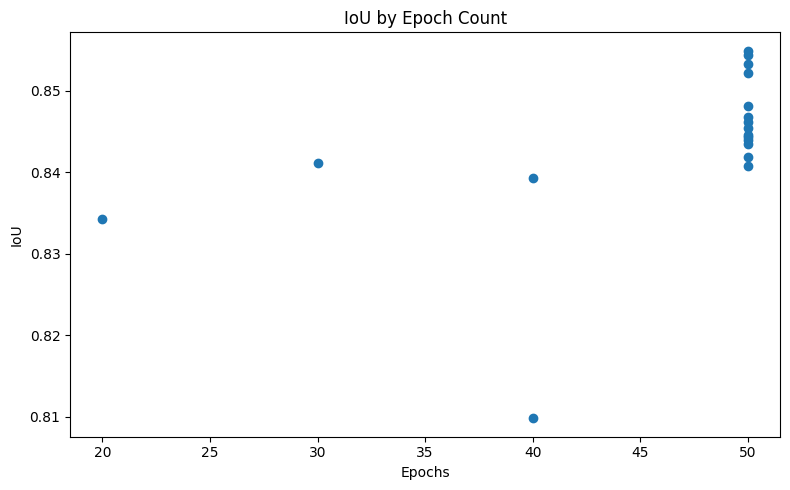

In [6]:
plt.figure(figsize=(8, 5))
plt.scatter(df["epoch"], df["iou"])
plt.xlabel("Epochs")
plt.ylabel("IoU")
plt.title("IoU by Epoch Count")
plt.tight_layout()
plt.show()

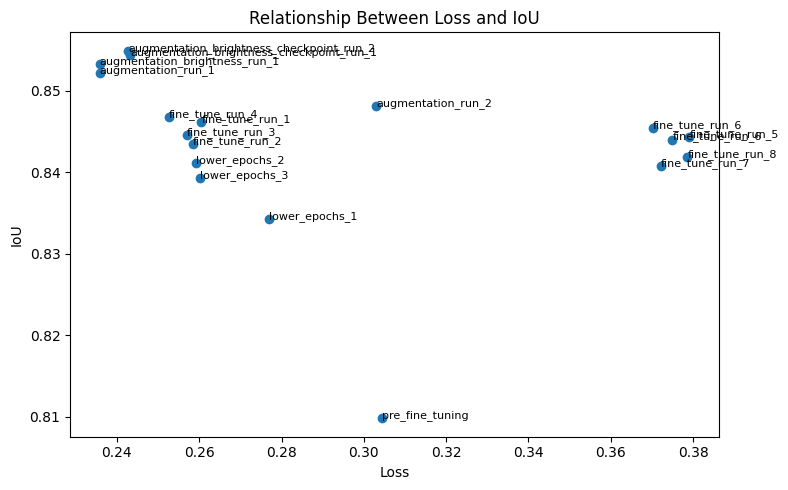

In [7]:
plt.figure(figsize=(8, 5))
plt.scatter(df["loss"], df["iou"])

for _, row in df.iterrows():
    plt.annotate(row["run_name"], (row["loss"], row["iou"]), fontsize=8)

plt.xlabel("Loss")
plt.ylabel("IoU")
plt.title("Relationship Between Loss and IoU")
plt.tight_layout()
plt.show()

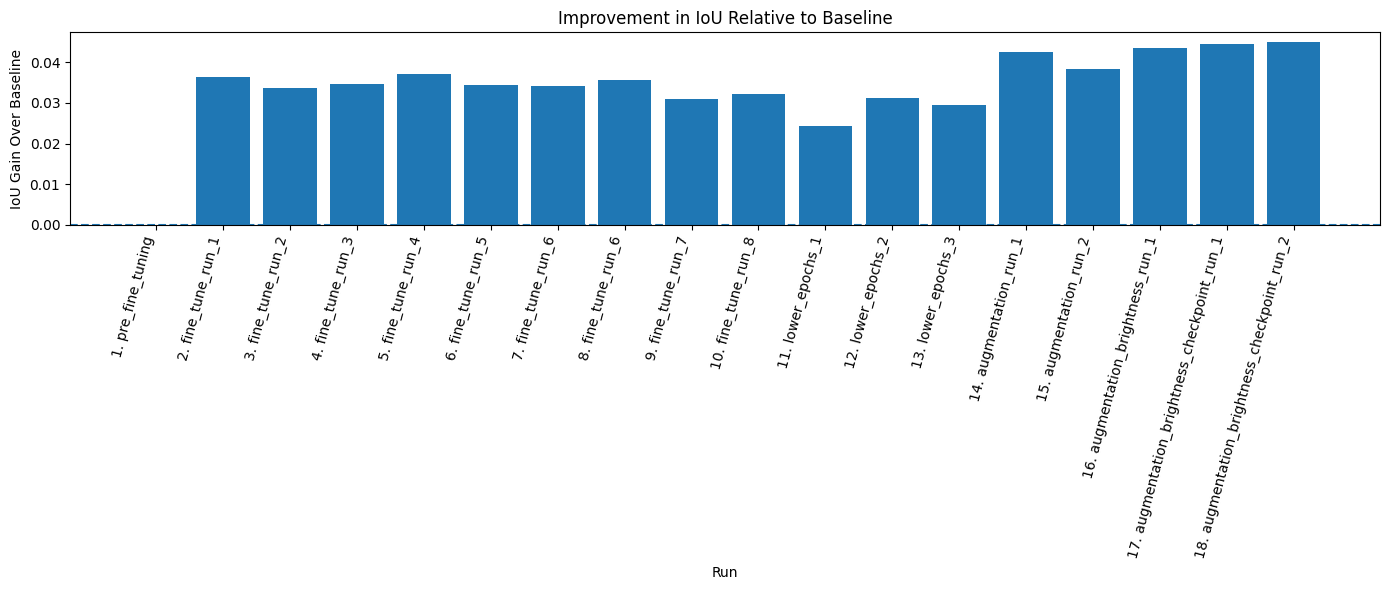

In [8]:
baseline_iou = df.loc[df["run_name"] == "pre_fine_tuning", "iou"].iloc[0]
df["iou_gain"] = df["iou"] - baseline_iou

plt.figure(figsize=(14, 6))
plt.bar(df["label"], df["iou_gain"])
plt.axhline(0, linestyle="--")
plt.xticks(rotation=75, ha="right")
plt.ylabel("IoU Gain Over Baseline")
plt.xlabel("Run")
plt.title("Improvement in IoU Relative to Baseline")
plt.tight_layout()
plt.show()

In [9]:
def classify_run(row):
    note = str(row["notes"]).lower()
    name = str(row["run_name"]).lower()

    if "baseline" in note or "pre_fine_tuning" in name:
        return "baseline"
    elif "20 epochs" in note or "30 epochs" in note or "40 epochs" in note or "lower_epochs" in name:
        return "epoch study"
    elif "brightness" in note:
        return "augmentation + brightness"
    elif "flip + rotate" in note:
        return "augmentation"
    elif "tversky" in note or "bce and dice" in note:
        return "loss function study"
    else:
        return "fine-tuning"

df["group"] = df.apply(classify_run, axis=1)

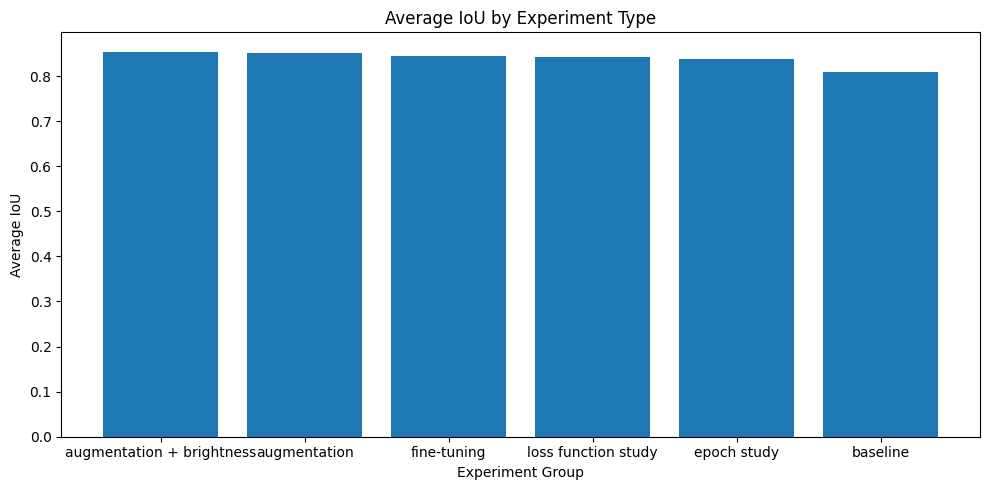

In [10]:
group_summary = df.groupby("group", as_index=False)["iou"].mean().sort_values("iou", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(group_summary["group"], group_summary["iou"])
plt.ylabel("Average IoU")
plt.xlabel("Experiment Group")
plt.title("Average IoU by Experiment Type")
plt.tight_layout()
plt.show()

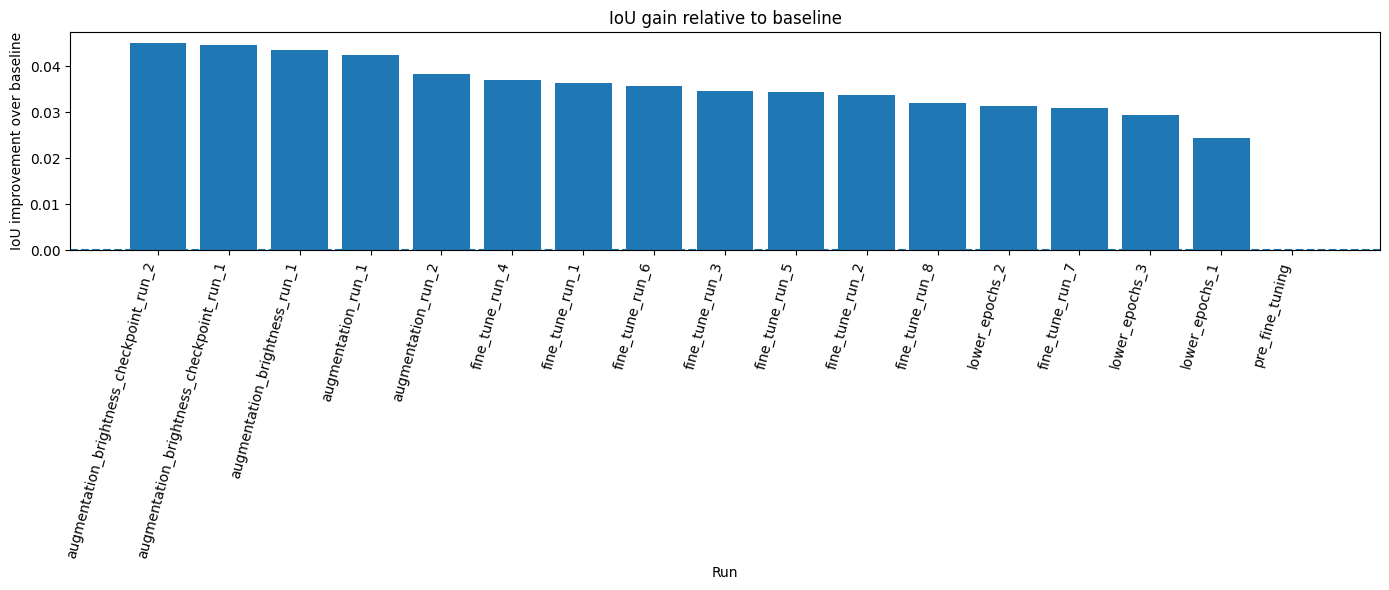

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "training_results_history.xlsx"
df = pd.read_excel(file_path).drop_duplicates()

baseline_iou = df.loc[df["run_name"] == "pre_fine_tuning", "iou"].iloc[0]
df["iou_gain"] = df["iou"] - baseline_iou

df_sorted = df.sort_values("iou_gain", ascending=False)

plt.figure(figsize=(14, 6))
plt.bar(df_sorted["run_name"], df_sorted["iou_gain"])
plt.axhline(0, linestyle="--")
plt.xticks(rotation=75, ha="right")
plt.ylabel("IoU improvement over baseline")
plt.xlabel("Run")
plt.title("IoU gain relative to baseline")
plt.tight_layout()
plt.show()

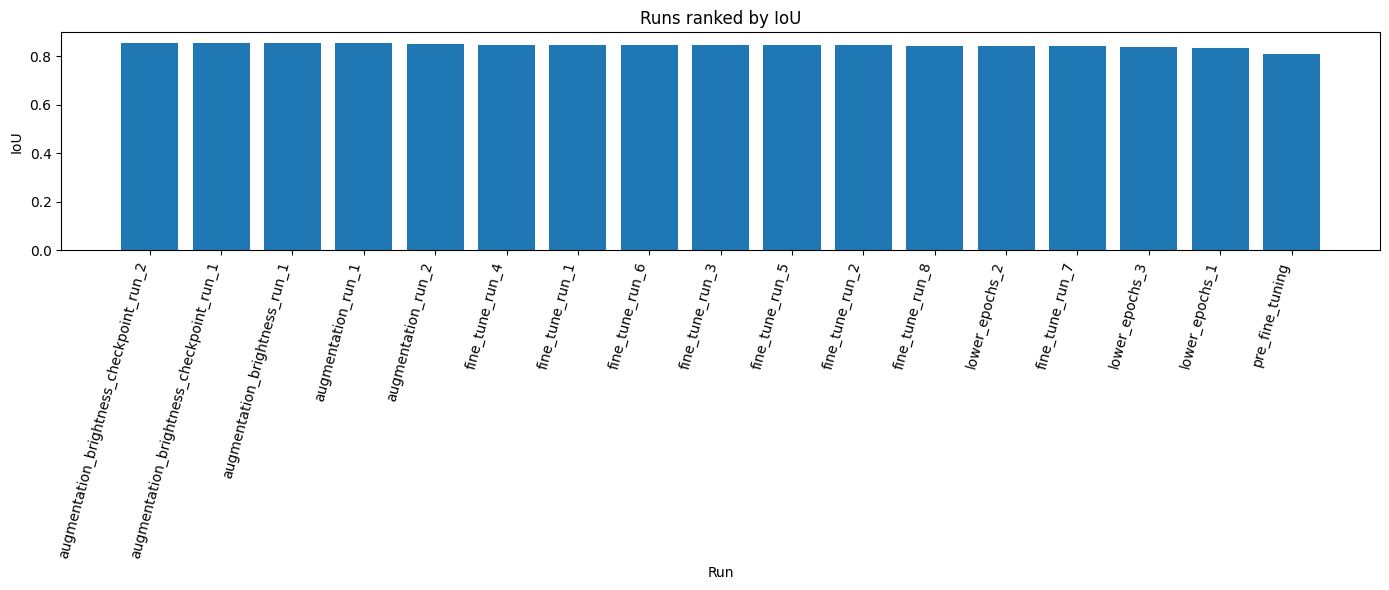

In [13]:
df_sorted = df.sort_values("iou", ascending=False)

plt.figure(figsize=(14, 6))
plt.bar(df_sorted["run_name"], df_sorted["iou"])
plt.xticks(rotation=75, ha="right")
plt.ylabel("IoU")
plt.xlabel("Run")
plt.title("Runs ranked by IoU")
plt.tight_layout()
plt.show()

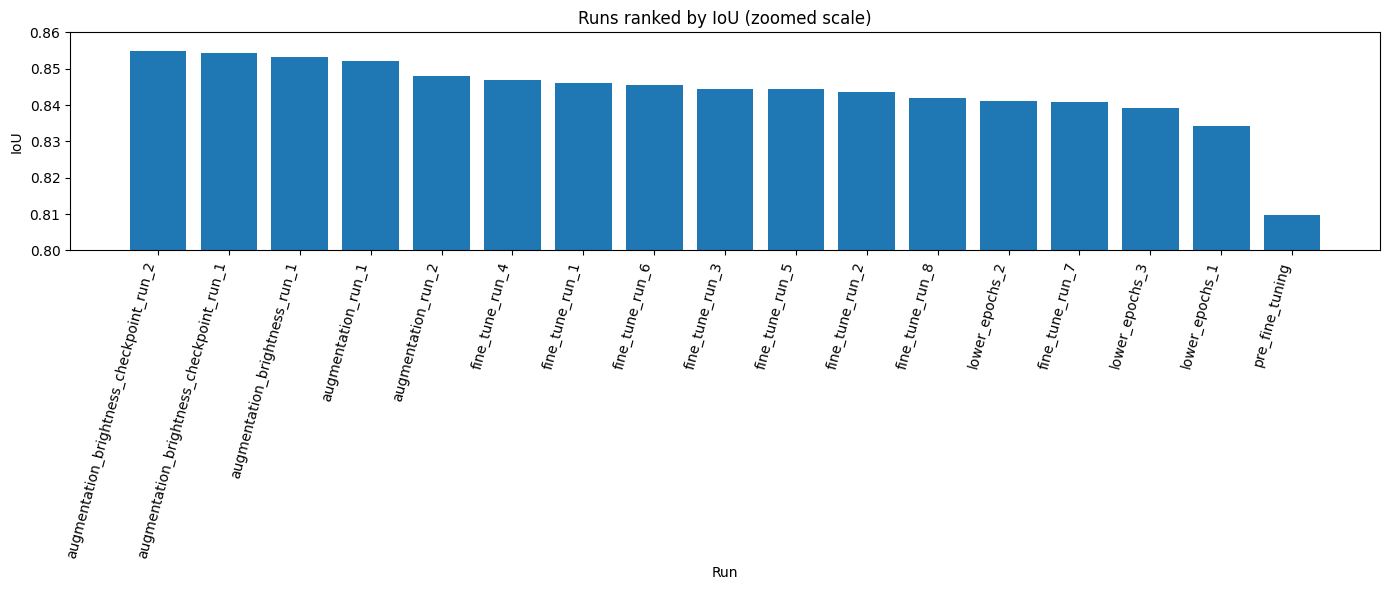

In [14]:
plt.figure(figsize=(14, 6))
plt.bar(df_sorted["run_name"], df_sorted["iou"])
plt.xticks(rotation=75, ha="right")
plt.ylabel("IoU")
plt.xlabel("Run")
plt.title("Runs ranked by IoU (zoomed scale)")
plt.ylim(0.80, 0.86)
plt.tight_layout()
plt.show()

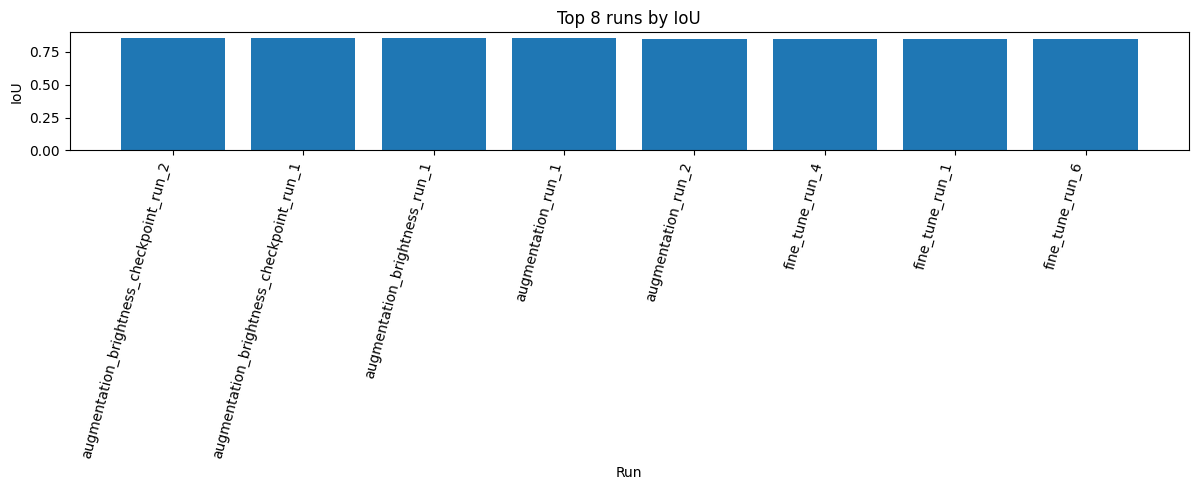

In [15]:
top_runs = df.sort_values("iou", ascending=False).head(8)

plt.figure(figsize=(12, 5))
plt.bar(top_runs["run_name"], top_runs["iou"])
plt.xticks(rotation=75, ha="right")
plt.ylabel("IoU")
plt.xlabel("Run")
plt.title("Top 8 runs by IoU")
plt.tight_layout()
plt.show()

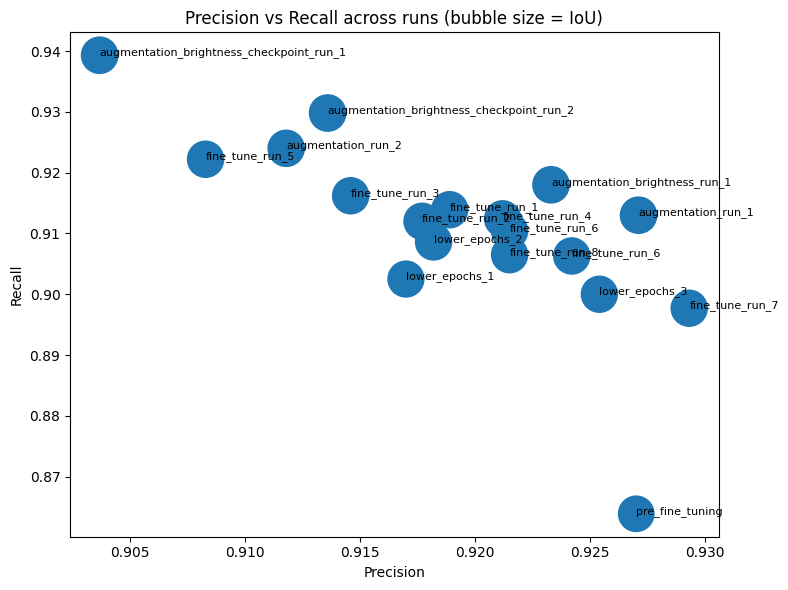

In [16]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(df["precision"], df["recall"], s=df["iou"] * 800)

for _, row in df.iterrows():
    plt.annotate(row["run_name"], (row["precision"], row["recall"]), fontsize=8)

plt.xlabel("Precision")
plt.ylabel("Recall")
plt.title("Precision vs Recall across runs (bubble size = IoU)")
plt.tight_layout()
plt.show()

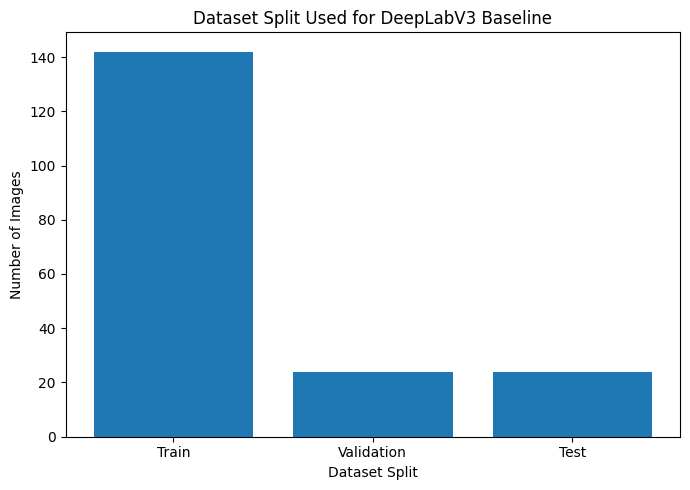

In [17]:
import matplotlib.pyplot as plt

splits = ["Train", "Validation", "Test"]
counts = [142, 24, 24]

plt.figure(figsize=(7, 5))
plt.bar(splits, counts)
plt.ylabel("Number of Images")
plt.xlabel("Dataset Split")
plt.title("Dataset Split Used for DeepLabV3 Baseline")
plt.tight_layout()
plt.show()

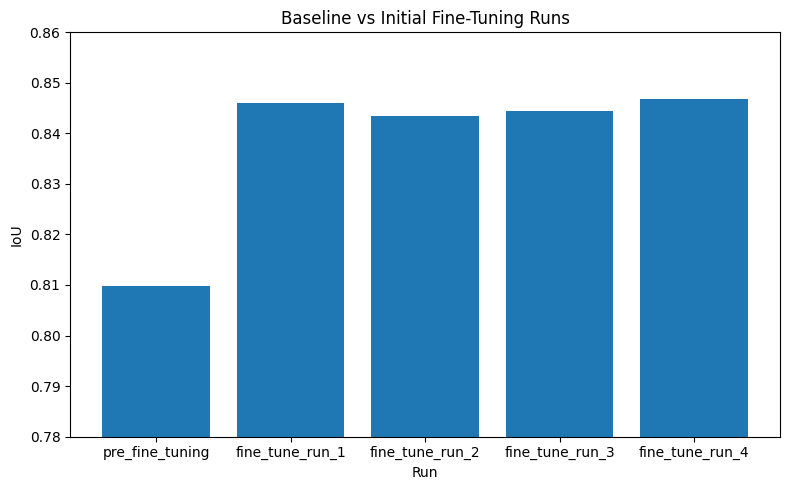

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "training_results_history.xlsx"
df = pd.read_excel(file_path)

# keep only the baseline and first fine-tuning runs
runs_to_plot = [
    "pre_fine_tuning",
    "fine_tune_run_1",
    "fine_tune_run_2",
    "fine_tune_run_3",
    "fine_tune_run_4",
]

plot_df = df[df["run_name"].isin(runs_to_plot)].copy()

# keep the first instance if there are duplicates elsewhere
plot_df = plot_df.drop_duplicates(subset=["run_name"], keep="first")

# order the runs properly
plot_df["run_name"] = pd.Categorical(
    plot_df["run_name"],
    categories=runs_to_plot,
    ordered=True
)
plot_df = plot_df.sort_values("run_name")

plt.figure(figsize=(8, 5))
plt.bar(plot_df["run_name"], plot_df["iou"])
plt.ylabel("IoU")
plt.xlabel("Run")
plt.title("Baseline vs Initial Fine-Tuning Runs")
plt.ylim(0.78, 0.86)
plt.tight_layout()
plt.show()

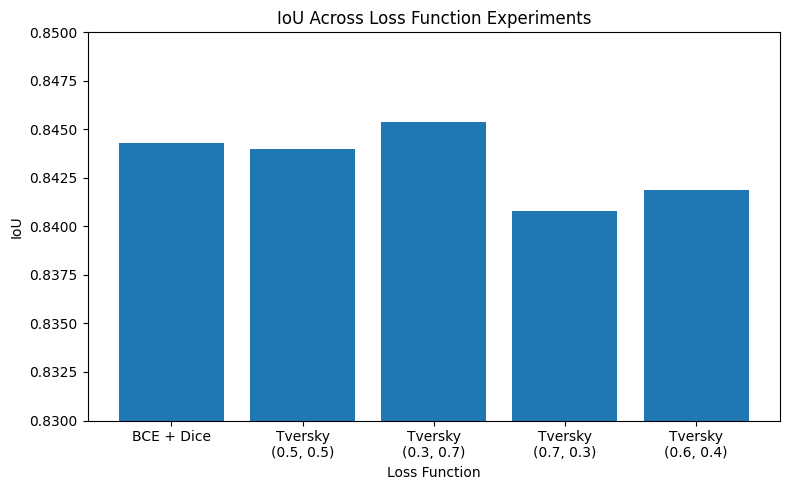

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "training_results_history.xlsx"
df = pd.read_excel(file_path)

# pick only the loss-function runs
plot_df = df.iloc[5:10].copy()

labels = [
    "BCE + Dice",
    "Tversky\n(0.5, 0.5)",
    "Tversky\n(0.3, 0.7)",
    "Tversky\n(0.7, 0.3)",
    "Tversky\n(0.6, 0.4)",
]

plot_df["label"] = labels

plt.figure(figsize=(8, 5))
plt.bar(plot_df["label"], plot_df["iou"])
plt.ylabel("IoU")
plt.xlabel("Loss Function")
plt.title("IoU Across Loss Function Experiments")
plt.ylim(0.83, 0.85)
plt.tight_layout()
plt.show()

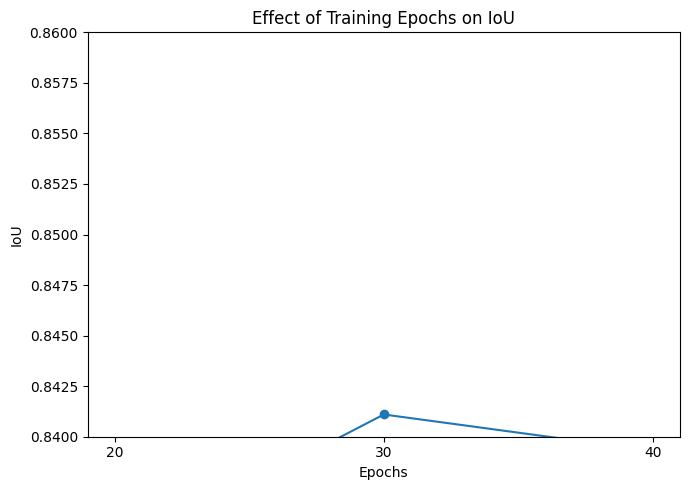

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "training_results_history.xlsx"
df = pd.read_excel(file_path)

# epoch testing runs
runs_to_plot = ["lower_epochs_1", "lower_epochs_2", "lower_epochs_3"]
plot_df = df[df["run_name"].isin(runs_to_plot)].copy()

# map runs to actual epoch values
epoch_map = {
    "lower_epochs_1": 20,
    "lower_epochs_2": 30,
    "lower_epochs_3": 40,
}

plot_df["epochs"] = plot_df["run_name"].map(epoch_map)
plot_df = plot_df.sort_values("epochs")

plt.figure(figsize=(7, 5))
plt.plot(plot_df["epochs"], plot_df["iou"], marker="o")
plt.xlabel("Epochs")
plt.ylabel("IoU")
plt.title("Effect of Training Epochs on IoU")
plt.xticks([20, 30, 40])
plt.ylim(0.84, 0.86)
plt.tight_layout()
plt.show()

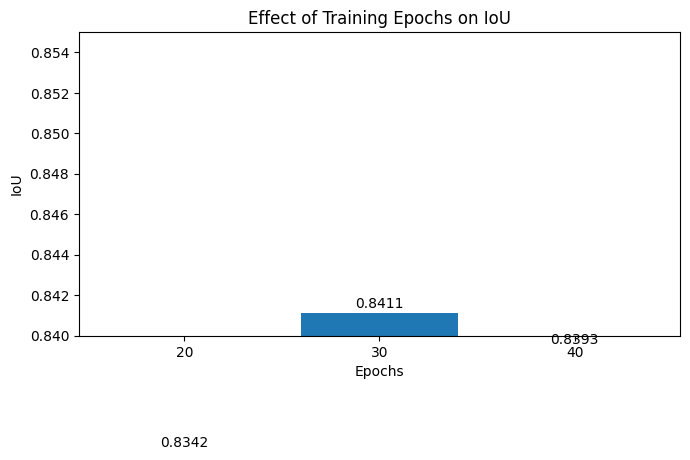

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "training_results_history.xlsx"
df = pd.read_excel(file_path)

runs_to_plot = ["lower_epochs_1", "lower_epochs_2", "lower_epochs_3"]
plot_df = df[df["run_name"].isin(runs_to_plot)].copy()

epoch_map = {
    "lower_epochs_1": 20,
    "lower_epochs_2": 30,
    "lower_epochs_3": 40,
}

plot_df["epochs"] = plot_df["run_name"].map(epoch_map)
plot_df = plot_df.sort_values("epochs")

plt.figure(figsize=(7, 5))
plt.bar(plot_df["epochs"].astype(str), plot_df["iou"])

for _, row in plot_df.iterrows():
    plt.text(
        x=str(row["epochs"]),
        y=row["iou"] + 0.0003,
        s=f"{row['iou']:.4f}",
        ha="center"
    )

plt.xlabel("Epochs")
plt.ylabel("IoU")
plt.title("Effect of Training Epochs on IoU")
plt.ylim(0.84, 0.855)
plt.tight_layout()
plt.show()

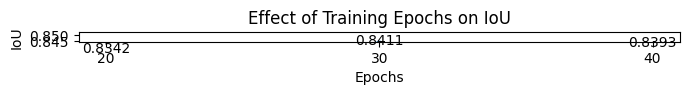

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "training_results_history.xlsx"
df = pd.read_excel(file_path)

runs_to_plot = ["lower_epochs_1", "lower_epochs_2", "lower_epochs_3"]
plot_df = df[df["run_name"].isin(runs_to_plot)].copy()

epoch_map = {
    "lower_epochs_1": 20,
    "lower_epochs_2": 30,
    "lower_epochs_3": 40,
}

plot_df["epochs"] = plot_df["run_name"].map(epoch_map)
plot_df = plot_df.sort_values("epochs")

plt.figure(figsize=(7, 5))
plt.plot(plot_df["epochs"], plot_df["iou"], marker="o")

for _, row in plot_df.iterrows():
    plt.text(row["epochs"], row["iou"] + 0.0002, f"{row['iou']:.4f}", ha="center")

plt.xlabel("Epochs")
plt.ylabel("IoU")
plt.title("Effect of Training Epochs on IoU")
plt.xticks([20, 30, 40])
plt.ylim(0.844, 0.8525)
plt.tight_layout()
plt.show()

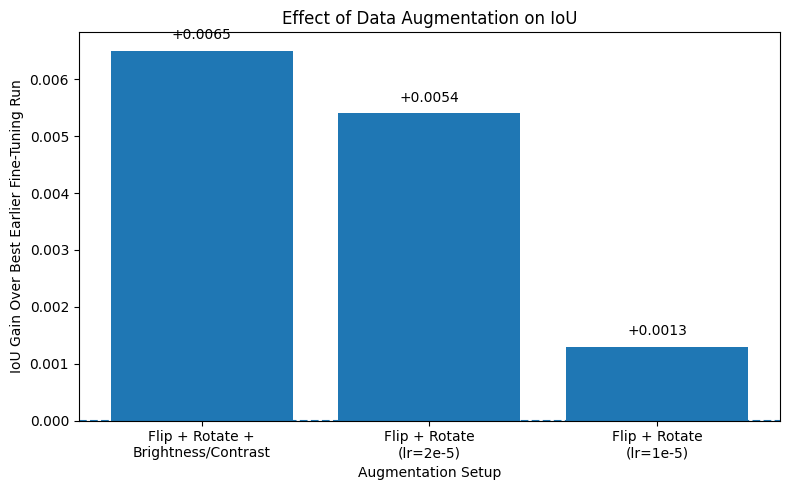

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "training_results_history.xlsx"
df = pd.read_excel(file_path).drop_duplicates()

runs_to_plot = [
    "augmentation_run_1",
    "augmentation_run_2",
    "augmentation_brightness_run_1",
]

plot_df = df[df["run_name"].isin(runs_to_plot)].copy()

label_map = {
    "augmentation_run_1": "Flip + Rotate\n(lr=2e-5)",
    "augmentation_run_2": "Flip + Rotate\n(lr=1e-5)",
    "augmentation_brightness_run_1": "Flip + Rotate +\nBrightness/Contrast",
}

plot_df["label"] = plot_df["run_name"].map(label_map)

# best earlier non-augmentation run from the fine-tuning stage
best_previous_iou = 0.8468
plot_df["iou_gain"] = plot_df["iou"] - best_previous_iou

plot_df = plot_df.sort_values("iou_gain", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(plot_df["label"], plot_df["iou_gain"])

for _, row in plot_df.iterrows():
    plt.text(
        row["label"],
        row["iou_gain"] + 0.0002,
        f"{row['iou_gain']:+.4f}",
        ha="center"
    )

plt.axhline(0, linestyle="--")
plt.ylabel("IoU Gain Over Best Earlier Fine-Tuning Run")
plt.xlabel("Augmentation Setup")
plt.title("Effect of Data Augmentation on IoU")
plt.tight_layout()
plt.show()

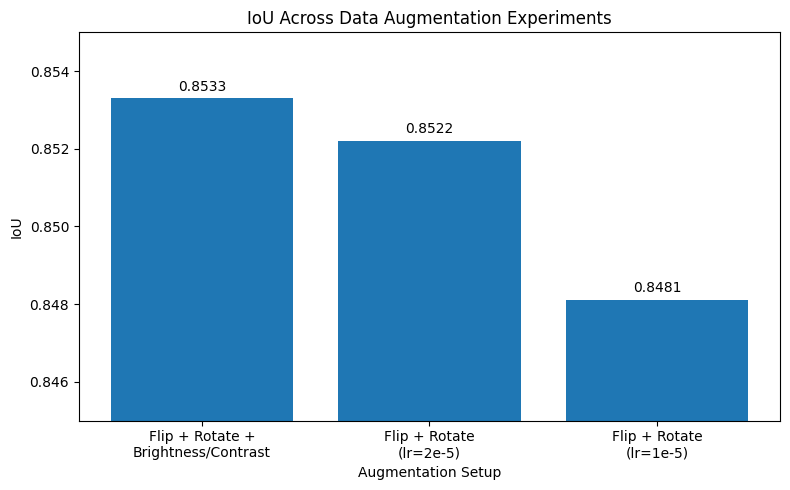

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "training_results_history.xlsx"
df = pd.read_excel(file_path).drop_duplicates()

runs_to_plot = [
    "augmentation_run_1",
    "augmentation_run_2",
    "augmentation_brightness_run_1",
]

plot_df = df[df["run_name"].isin(runs_to_plot)].copy()

label_map = {
    "augmentation_run_1": "Flip + Rotate\n(lr=2e-5)",
    "augmentation_run_2": "Flip + Rotate\n(lr=1e-5)",
    "augmentation_brightness_run_1": "Flip + Rotate +\nBrightness/Contrast",
}

plot_df["label"] = plot_df["run_name"].map(label_map)
plot_df = plot_df.sort_values("iou", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(plot_df["label"], plot_df["iou"])

for _, row in plot_df.iterrows():
    plt.text(
        row["label"],
        row["iou"] + 0.0002,
        f"{row['iou']:.4f}",
        ha="center"
    )

plt.ylabel("IoU")
plt.xlabel("Augmentation Setup")
plt.title("IoU Across Data Augmentation Experiments")
plt.ylim(0.845, 0.855)
plt.tight_layout()
plt.show()

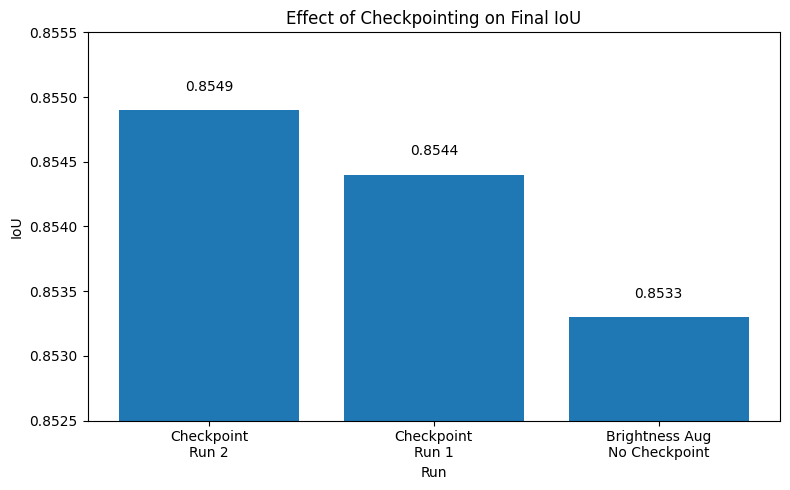

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "training_results_history.xlsx"
df = pd.read_excel(file_path).drop_duplicates()

runs_to_plot = [
    "augmentation_brightness_run_1",
    "augmentation_brightness_checkpoint_run_1",
    "augmentation_brightness_checkpoint_run_2",
]

plot_df = df[df["run_name"].isin(runs_to_plot)].copy()

label_map = {
    "augmentation_brightness_run_1": "Brightness Aug\nNo Checkpoint",
    "augmentation_brightness_checkpoint_run_1": "Checkpoint\nRun 1",
    "augmentation_brightness_checkpoint_run_2": "Checkpoint\nRun 2",
}

plot_df["label"] = plot_df["run_name"].map(label_map)
plot_df = plot_df.sort_values("iou", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(plot_df["label"], plot_df["iou"])

for _, row in plot_df.iterrows():
    plt.text(
        row["label"],
        row["iou"] + 0.00015,
        f"{row['iou']:.4f}",
        ha="center"
    )

plt.ylabel("IoU")
plt.xlabel("Run")
plt.title("Effect of Checkpointing on Final IoU")
plt.ylim(0.8525, 0.8555)
plt.tight_layout()
plt.show()

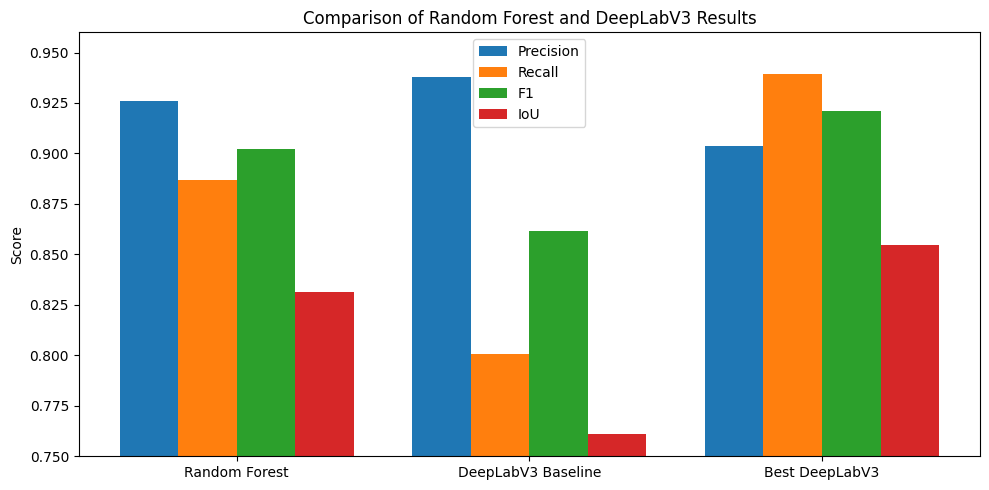

In [27]:
import matplotlib.pyplot as plt
import numpy as np

models = ["Random Forest", "DeepLabV3 Baseline", "Best DeepLabV3"]
precision = [0.9260, 0.9380, 0.9037]
recall = [0.8869, 0.8008, 0.9393]
f1 = [0.9024, 0.8617, 0.9210]
iou = [0.8313, 0.7609, 0.8549]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(10, 5))
plt.bar(x - 1.5*width, precision, width, label="Precision")
plt.bar(x - 0.5*width, recall, width, label="Recall")
plt.bar(x + 0.5*width, f1, width, label="F1")
plt.bar(x + 1.5*width, iou, width, label="IoU")

plt.xticks(x, models)
plt.ylim(0.75, 0.96)
plt.ylabel("Score")
plt.title("Comparison of Random Forest and DeepLabV3 Results")
plt.legend()
plt.tight_layout()
plt.show()

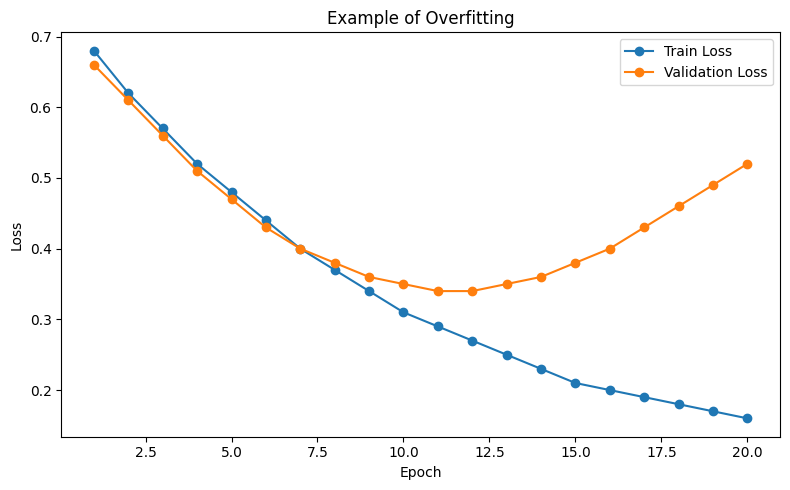

In [28]:
import matplotlib.pyplot as plt

epochs = list(range(1, 21))

# example only
train_loss = [0.68, 0.62, 0.57, 0.52, 0.48, 0.44, 0.40, 0.37, 0.34, 0.31,
              0.29, 0.27, 0.25, 0.23, 0.21, 0.20, 0.19, 0.18, 0.17, 0.16]

val_loss = [0.66, 0.61, 0.56, 0.51, 0.47, 0.43, 0.40, 0.38, 0.36, 0.35,
            0.34, 0.34, 0.35, 0.36, 0.38, 0.40, 0.43, 0.46, 0.49, 0.52]

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, marker="o", label="Train Loss")
plt.plot(epochs, val_loss, marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Example of Overfitting")
plt.legend()
plt.tight_layout()
plt.show()

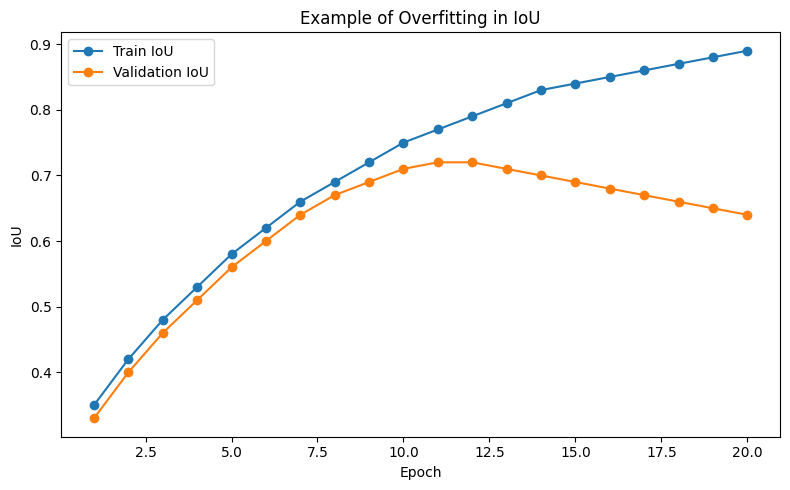

In [29]:
import matplotlib.pyplot as plt

epochs = list(range(1, 21))

# example only
train_iou = [0.35, 0.42, 0.48, 0.53, 0.58, 0.62, 0.66, 0.69, 0.72, 0.75,
             0.77, 0.79, 0.81, 0.83, 0.84, 0.85, 0.86, 0.87, 0.88, 0.89]

val_iou = [0.33, 0.40, 0.46, 0.51, 0.56, 0.60, 0.64, 0.67, 0.69, 0.71,
           0.72, 0.72, 0.71, 0.70, 0.69, 0.68, 0.67, 0.66, 0.65, 0.64]

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_iou, marker="o", label="Train IoU")
plt.plot(epochs, val_iou, marker="o", label="Validation IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title("Example of Overfitting in IoU")
plt.legend()
plt.tight_layout()
plt.show()

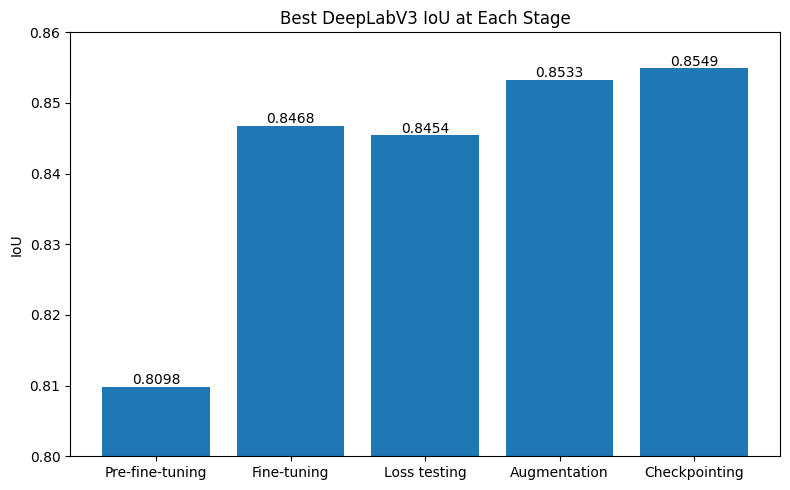

In [30]:
import matplotlib.pyplot as plt

stages = [
    "Pre-fine-tuning",
    "Fine-tuning",
    "Loss testing",
    "Augmentation",
    "Checkpointing"
]

best_iou = [0.8098, 0.8468, 0.8454, 0.8533, 0.8549]

plt.figure(figsize=(8, 5))
plt.bar(stages, best_iou)

for i, v in enumerate(best_iou):
    plt.text(i, v + 0.0004, f"{v:.4f}", ha="center")

plt.ylabel("IoU")
plt.title("Best DeepLabV3 IoU at Each Stage")
plt.ylim(0.80, 0.86)
plt.tight_layout()
plt.show()

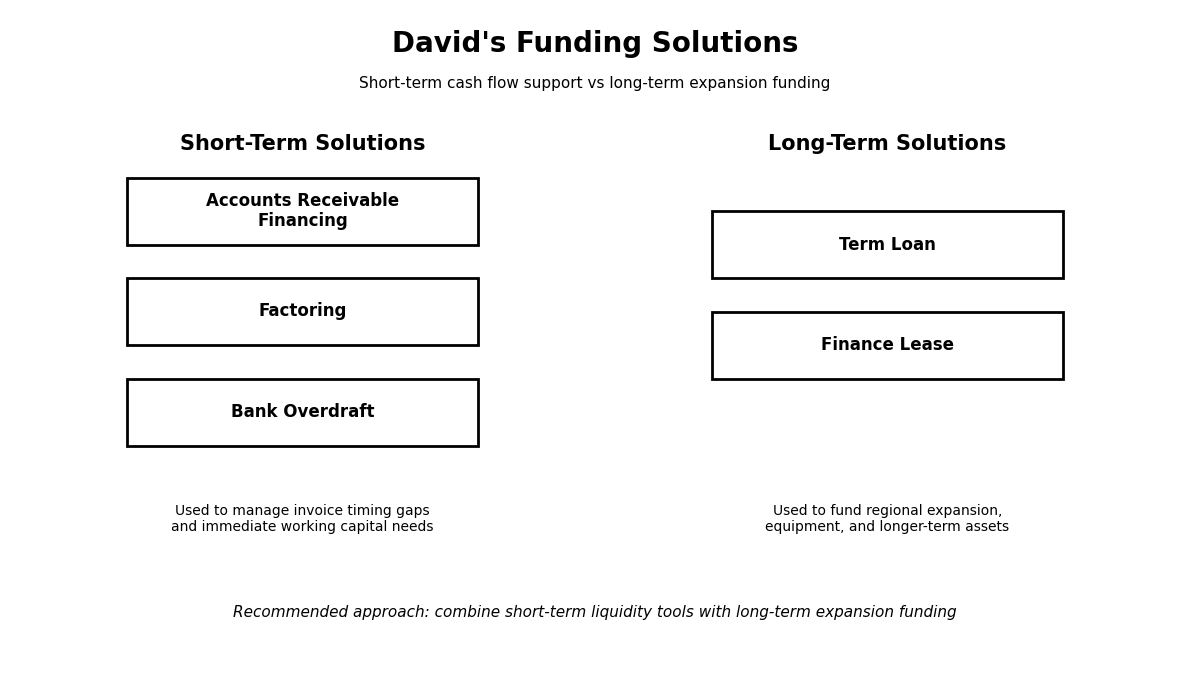

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# ----------------------------
# data
# ----------------------------
short_term = [
    "Accounts Receivable\nFinancing",
    "Factoring",
    "Bank Overdraft"
]

long_term = [
    "Term Loan",
    "Finance Lease"
]

# ----------------------------
# figure setup
# ----------------------------
fig, ax = plt.subplots(figsize=(12, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis("off")

# ----------------------------
# title
# ----------------------------
ax.text(
    5, 9.5,
    "David's Funding Solutions",
    ha="center",
    va="center",
    fontsize=20,
    fontweight="bold"
)

ax.text(
    5, 8.9,
    "Short-term cash flow support vs long-term expansion funding",
    ha="center",
    va="center",
    fontsize=11
)

# ----------------------------
# section headers
# ----------------------------
ax.text(
    2.5, 8.0,
    "Short-Term Solutions",
    ha="center",
    va="center",
    fontsize=15,
    fontweight="bold"
)

ax.text(
    7.5, 8.0,
    "Long-Term Solutions",
    ha="center",
    va="center",
    fontsize=15,
    fontweight="bold"
)

# ----------------------------
# draw boxes
# ----------------------------
def draw_box(x, y, w, h, text):
    rect = Rectangle((x, y), w, h, fill=False, linewidth=2)
    ax.add_patch(rect)
    ax.text(
        x + w / 2,
        y + h / 2,
        text,
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold"
    )

# short-term boxes
short_y_positions = [6.5, 5.0, 3.5]
for y, label in zip(short_y_positions, short_term):
    draw_box(1.0, y, 3.0, 1.0, label)

# long-term boxes
long_y_positions = [6.0, 4.5]
for y, label in zip(long_y_positions, long_term):
    draw_box(6.0, y, 3.0, 1.0, label)

# ----------------------------
# optional labels under each side
# ----------------------------
ax.text(
    2.5, 2.4,
    "Used to manage invoice timing gaps\nand immediate working capital needs",
    ha="center",
    va="center",
    fontsize=10
)

ax.text(
    7.5, 2.4,
    "Used to fund regional expansion,\nequipment, and longer-term assets",
    ha="center",
    va="center",
    fontsize=10
)

# ----------------------------
# optional bottom note
# ----------------------------
ax.text(
    5, 1.0,
    "Recommended approach: combine short-term liquidity tools with long-term expansion funding",
    ha="center",
    va="center",
    fontsize=11,
    style="italic"
)

# ----------------------------
# save + show
# ----------------------------
plt.tight_layout()
plt.savefig("david_funding_solutions_chart.png", dpi=300, bbox_inches="tight")
plt.show()

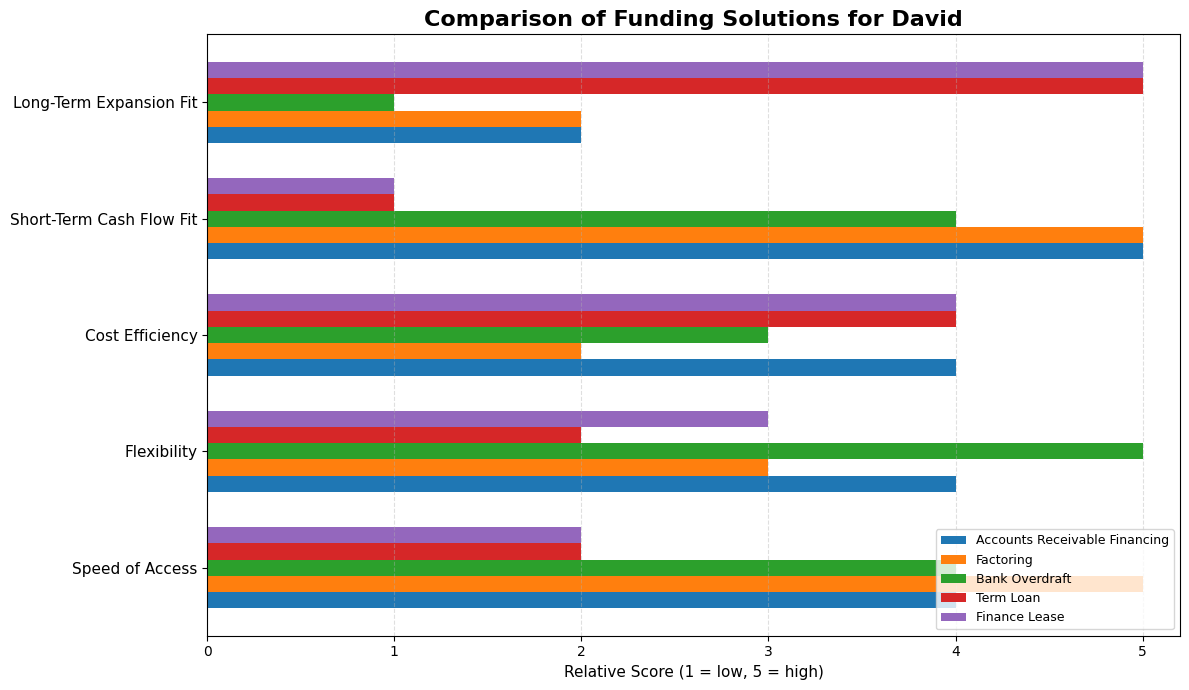

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# data
# ----------------------------
solutions = [
    "Accounts Receivable Financing",
    "Factoring",
    "Bank Overdraft",
    "Term Loan",
    "Finance Lease"
]

criteria = [
    "Speed of Access",
    "Flexibility",
    "Cost Efficiency",
    "Short-Term Cash Flow Fit",
    "Long-Term Expansion Fit"
]

# scores out of 5 based on your script logic
scores = {
    "Accounts Receivable Financing": [4, 4, 4, 5, 2],
    "Factoring": [5, 3, 2, 5, 2],
    "Bank Overdraft": [4, 5, 3, 4, 1],
    "Term Loan": [2, 2, 4, 1, 5],
    "Finance Lease": [2, 3, 4, 1, 5]
}

# ----------------------------
# plotting setup
# ----------------------------
y = np.arange(len(criteria))
bar_height = 0.14

fig, ax = plt.subplots(figsize=(12, 7))

offsets = np.linspace(-2, 2, len(solutions)) * bar_height

for i, solution in enumerate(solutions):
    ax.barh(
        y + offsets[i],
        scores[solution],
        height=bar_height,
        label=solution
    )

# ----------------------------
# formatting
# ----------------------------
ax.set_yticks(y)
ax.set_yticklabels(criteria, fontsize=11)
ax.set_xlim(0, 5.2)
ax.set_xlabel("Relative Score (1 = low, 5 = high)", fontsize=11)
ax.set_title("Comparison of Funding Solutions for David", fontsize=16, fontweight="bold")

ax.legend(
    loc="lower right",
    fontsize=9,
    frameon=True
)

ax.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("david_solution_comparison_chart.png", dpi=300, bbox_inches="tight")
plt.show()

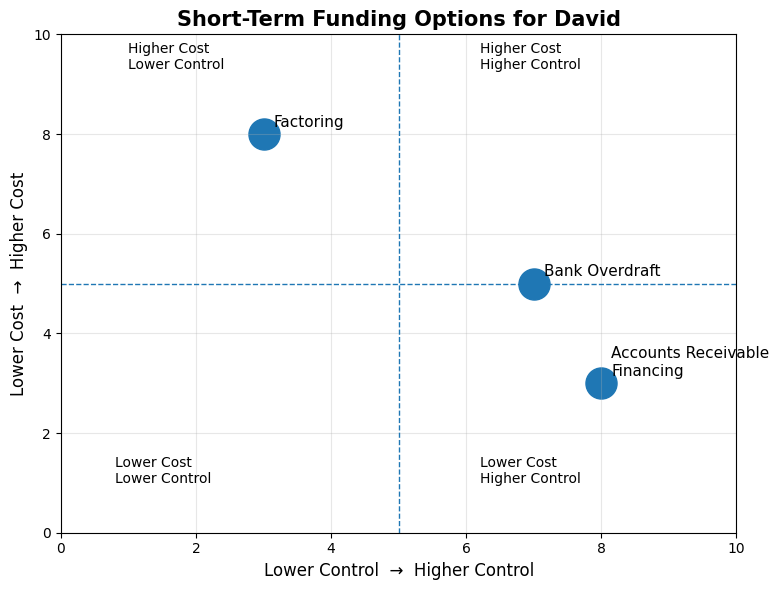

In [3]:
import matplotlib.pyplot as plt

# ----------------------------
# data
# ----------------------------
solutions = [
    "Accounts Receivable\nFinancing",
    "Factoring",
    "Bank Overdraft"
]

# x = control, y = cost
x = [8, 3, 7]
y = [3, 8, 5]

# ----------------------------
# plot
# ----------------------------
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(x, y, s=500)

for i, label in enumerate(solutions):
    ax.text(x[i] + 0.15, y[i] + 0.15, label, fontsize=11)

# axes
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)

ax.set_xlabel("Lower Control  →  Higher Control", fontsize=12)
ax.set_ylabel("Lower Cost  →  Higher Cost", fontsize=12)
ax.set_title("Short-Term Funding Options for David", fontsize=15, fontweight="bold")

# quadrant guide lines
ax.axhline(5, linestyle="--", linewidth=1)
ax.axvline(5, linestyle="--", linewidth=1)

# optional quadrant labels
ax.text(1, 9.3, "Higher Cost\nLower Control", fontsize=10)
ax.text(6.2, 9.3, "Higher Cost\nHigher Control", fontsize=10)
ax.text(0.8, 1.0, "Lower Cost\nLower Control", fontsize=10)
ax.text(6.2, 1.0, "Lower Cost\nHigher Control", fontsize=10)

ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("short_term_funding_positioning_chart.png", dpi=300, bbox_inches="tight")
plt.show()

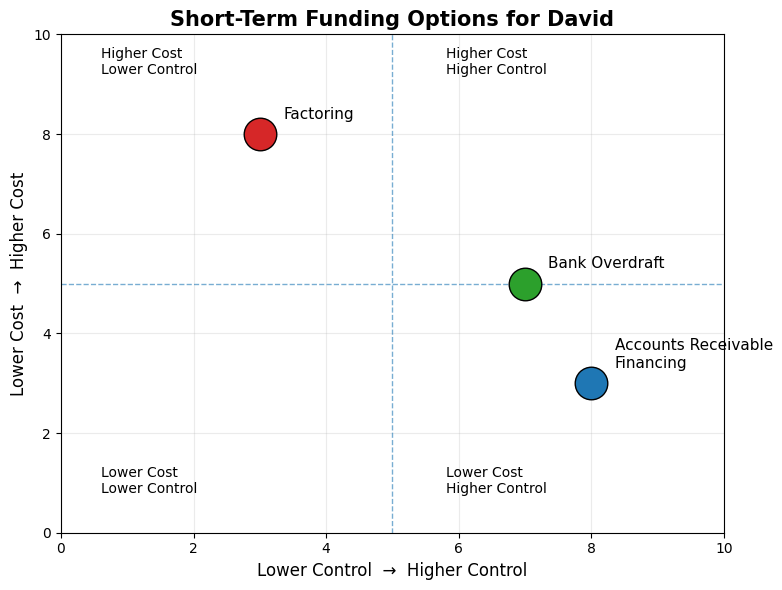

In [5]:
import matplotlib.pyplot as plt

# ----------------------------
# data
# x = control
# y = cost
# these are relative/qualitative positions based on your script
# ----------------------------
solutions = [
    "Accounts Receivable\nFinancing",
    "Factoring",
    "Bank Overdraft"
]

x = [8, 3, 7]
y = [3, 8, 5]

colors = [
    "tab:blue",
    "tab:red",
    "tab:green"
]

# extra padding for labels
x_pad = 0.35
y_pad = 0.25

# ----------------------------
# plot
# ----------------------------
fig, ax = plt.subplots(figsize=(8, 6))

for i, label in enumerate(solutions):
    ax.scatter(
        x[i], y[i],
        s=550,
        color=colors[i],
        edgecolor="black",
        linewidth=1.0,
        zorder=3
    )
    ax.text(
        x[i] + x_pad,
        y[i] + y_pad,
        label,
        fontsize=11,
        ha="left",
        va="bottom"
    )

# axes
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)

ax.set_xlabel("Lower Control  →  Higher Control", fontsize=12)
ax.set_ylabel("Lower Cost  →  Higher Cost", fontsize=12)
ax.set_title("Short-Term Funding Options for David", fontsize=15, fontweight="bold")

# guide lines
ax.axhline(5, linestyle="--", linewidth=1, alpha=0.6)
ax.axvline(5, linestyle="--", linewidth=1, alpha=0.6)

# quadrant labels
ax.text(0.6, 9.2, "Higher Cost\nLower Control", fontsize=10, ha="left")
ax.text(5.8, 9.2, "Higher Cost\nHigher Control", fontsize=10, ha="left")
ax.text(0.6, 0.8, "Lower Cost\nLower Control", fontsize=10, ha="left")
ax.text(5.8, 0.8, "Lower Cost\nHigher Control", fontsize=10, ha="left")

# light grid
ax.grid(alpha=0.25, zorder=0)

plt.tight_layout()
# plt.savefig("short_term_funding_positioning_chart.png", dpi=300, bbox_inches="tight")
plt.show()

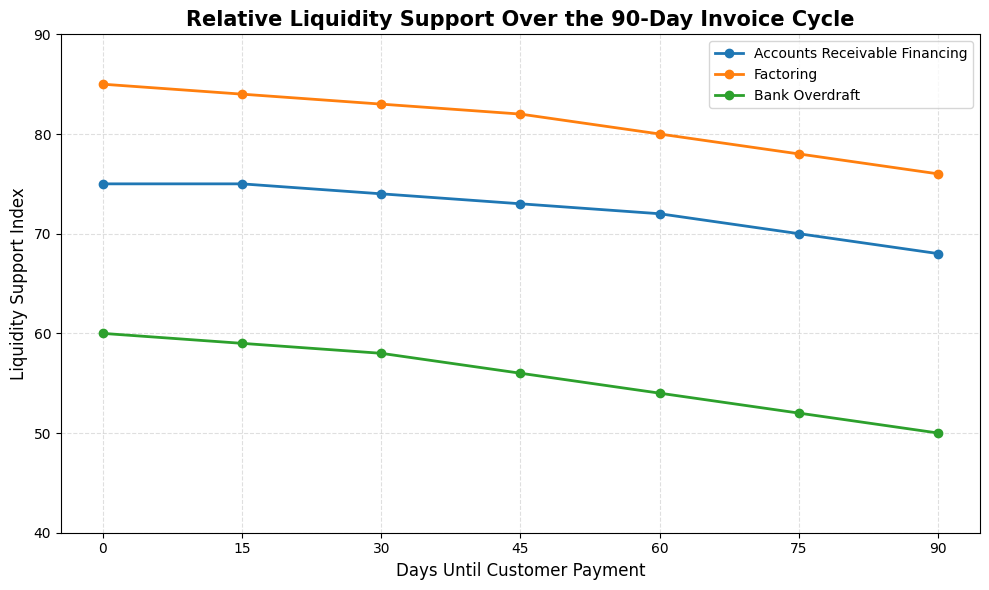

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# illustrative timeline
# ----------------------------
days = np.array([0, 15, 30, 45, 60, 75, 90])

# relative liquidity support index (illustrative, not real market data)
# higher = more immediate cash support during invoice waiting period
receivables_finance = np.array([75, 75, 74, 73, 72, 70, 68])
factoring = np.array([85, 84, 83, 82, 80, 78, 76])
overdraft = np.array([60, 59, 58, 56, 54, 52, 50])

# ----------------------------
# plot
# ----------------------------
plt.figure(figsize=(10, 6))

plt.plot(days, receivables_finance, marker='o', linewidth=2, label='Accounts Receivable Financing')
plt.plot(days, factoring, marker='o', linewidth=2, label='Factoring')
plt.plot(days, overdraft, marker='o', linewidth=2, label='Bank Overdraft')

# ----------------------------
# formatting
# ----------------------------
plt.title("Relative Liquidity Support Over the 90-Day Invoice Cycle", fontsize=15, fontweight="bold")
plt.xlabel("Days Until Customer Payment", fontsize=12)
plt.ylabel("Liquidity Support Index", fontsize=12)

plt.xticks(days)
plt.ylim(40, 90)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()

plt.savefig("liquidity_support_line_chart.png", dpi=300, bbox_inches="tight")
plt.show()

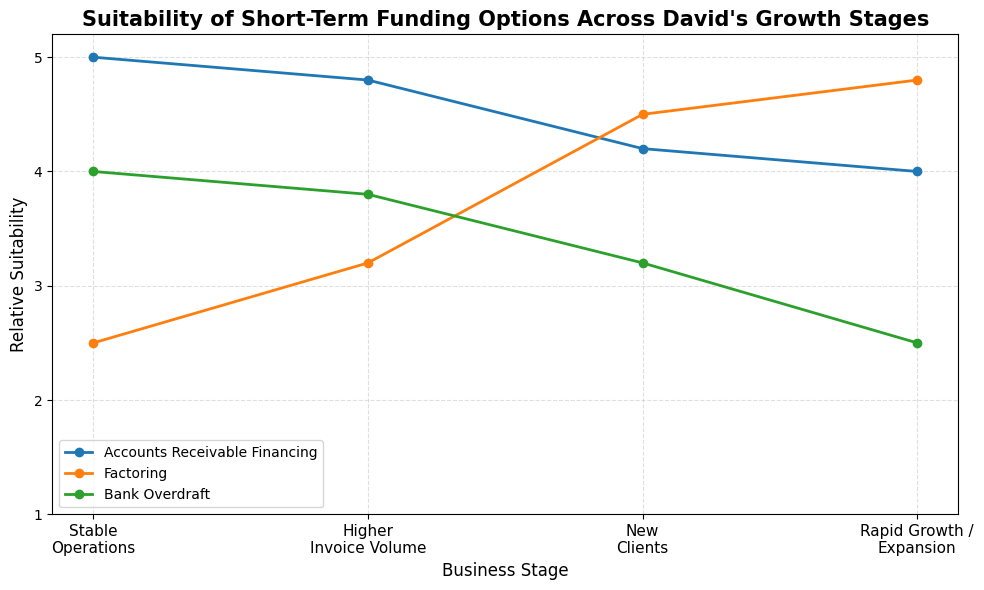

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# business stages
stages = [
    "Stable\nOperations",
    "Higher\nInvoice Volume",
    "New\nClients",
    "Rapid Growth /\nExpansion"
]
x = np.arange(len(stages))

# relative suitability scores (illustrative, based on your script)
receivables_finance = [5.0, 4.8, 4.2, 4.0]
factoring = [2.5, 3.2, 4.5, 4.8]
overdraft = [4.0, 3.8, 3.2, 2.5]

plt.figure(figsize=(10, 6))

plt.plot(x, receivables_finance, marker='o', linewidth=2, label='Accounts Receivable Financing')
plt.plot(x, factoring, marker='o', linewidth=2, label='Factoring')
plt.plot(x, overdraft, marker='o', linewidth=2, label='Bank Overdraft')

plt.xticks(x, stages, fontsize=11)
plt.yticks(np.arange(1, 6, 1))
plt.ylim(1, 5.2)

plt.xlabel("Business Stage", fontsize=12)
plt.ylabel("Relative Suitability", fontsize=12)
plt.title("Suitability of Short-Term Funding Options Across David's Growth Stages",
          fontsize=15, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()

plt.savefig("david_growth_stage_line_chart.png", dpi=300, bbox_inches="tight")
plt.show()

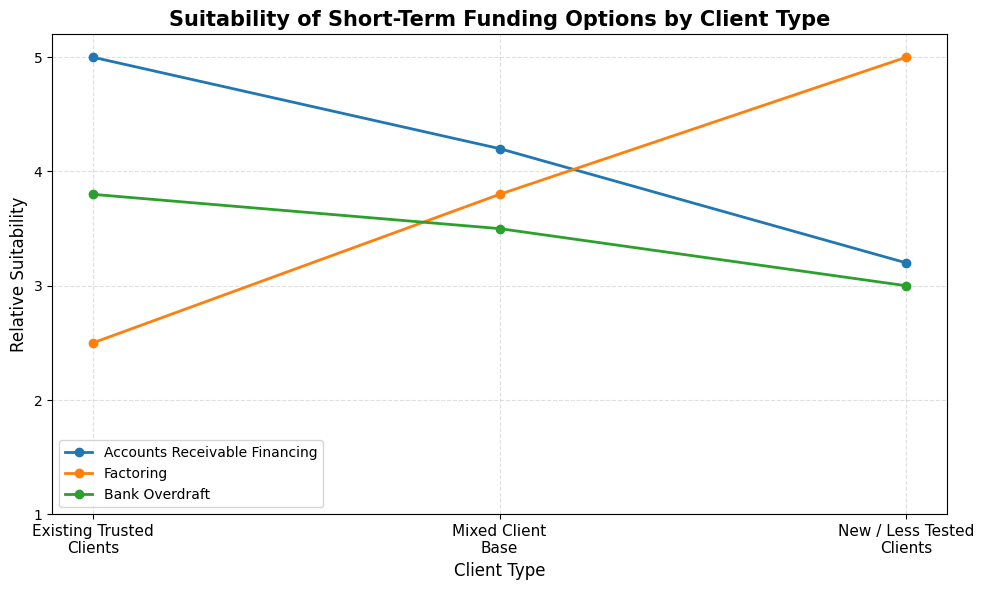

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# x-axis stages
client_types = [
    "Existing Trusted\nClients",
    "Mixed Client\nBase",
    "New / Less Tested\nClients"
]
x = np.arange(len(client_types))

# relative suitability scores (illustrative, based on your script logic)
# 1 = low suitability, 5 = high suitability
accounts_receivable_finance = [5.0, 4.2, 3.2]
factoring = [2.5, 3.8, 5.0]
bank_overdraft = [3.8, 3.5, 3.0]

plt.figure(figsize=(10, 6))

plt.plot(
    x,
    accounts_receivable_finance,
    marker='o',
    linewidth=2,
    label='Accounts Receivable Financing'
)

plt.plot(
    x,
    factoring,
    marker='o',
    linewidth=2,
    label='Factoring'
)

plt.plot(
    x,
    bank_overdraft,
    marker='o',
    linewidth=2,
    label='Bank Overdraft'
)

plt.xticks(x, client_types, fontsize=11)
plt.yticks(np.arange(1, 6, 1))
plt.ylim(1, 5.2)

plt.xlabel("Client Type", fontsize=12)
plt.ylabel("Relative Suitability", fontsize=12)
plt.title(
    "Suitability of Short-Term Funding Options by Client Type",
    fontsize=15,
    fontweight='bold'
)

plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()

plt.savefig("short_term_funding_by_client_type.png", dpi=300, bbox_inches="tight")
plt.show()

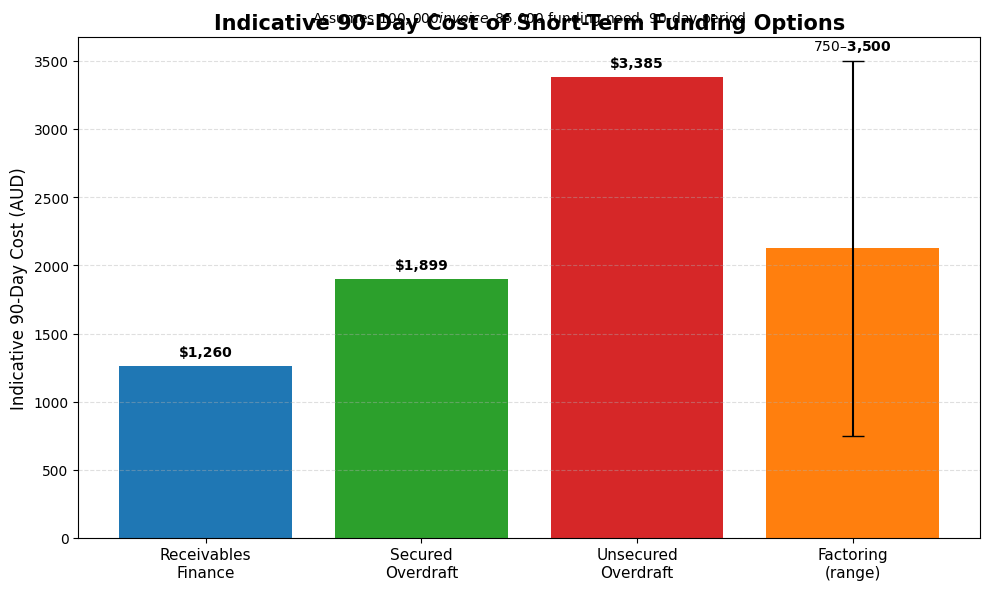

Indicative 90-day costs:
Receivables finance: $1,259.63
Secured overdraft:   $1,898.88
Unsecured overdraft: $3,385.45
Factoring range:     $750.00 to $3,500.00


In [9]:
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# assumptions
# ----------------------------
invoice_value = 100000
funding_amount = 85000
days = 90

# annual rates
receivables_rate = 0.0601          # 6.01% p.a.
secured_overdraft_rate = 0.0786    # 7.86% p.a.
secured_line_fee = 0.0120          # 1.20% p.a. on limit

unsecured_overdraft_rate = 0.1346  # 13.46% p.a.
unsecured_line_fee = 0.0150        # 1.50% p.a. on limit
unsecured_est_fee = 250            # $250

# factoring fee range on invoice value
factoring_low = 0.0075 * invoice_value   # 0.75%
factoring_high = 0.0350 * invoice_value  # 3.5%

# ----------------------------
# cost calculations
# ----------------------------
receivables_cost = funding_amount * receivables_rate * days / 365

secured_overdraft_cost = (
    funding_amount * secured_overdraft_rate * days / 365
    + funding_amount * secured_line_fee * days / 365
)

unsecured_overdraft_cost = (
    funding_amount * unsecured_overdraft_rate * days / 365
    + funding_amount * unsecured_line_fee * days / 365
    + unsecured_est_fee
)

# midpoint for plotting factoring as a range bar
factoring_mid = (factoring_low + factoring_high) / 2
factoring_err = (factoring_high - factoring_low) / 2

# values for fixed bars
labels = [
    "Receivables\nFinance",
    "Secured\nOverdraft",
    "Unsecured\nOverdraft",
    "Factoring\n(range)"
]

values = [
    receivables_cost,
    secured_overdraft_cost,
    unsecured_overdraft_cost,
    factoring_mid
]

colors = ["tab:blue", "tab:green", "tab:red", "tab:orange"]

# ----------------------------
# plot
# ----------------------------
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(labels))

# first three normal bars
ax.bar(x[:3], values[:3], color=colors[:3])

# factoring bar with error range
ax.bar(
    x[3],
    values[3],
    color=colors[3],
    yerr=factoring_err,
    capsize=8
)

# value labels
for i in range(3):
    ax.text(
        x[i],
        values[i] + 50,
        f"${values[i]:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# factoring range label
ax.text(
    x[3],
    values[3] + factoring_err + 50,
    f"${factoring_low:,.0f}–${factoring_high:,.0f}",
    ha="center",
    va="bottom",
    fontsize=10,
    fontweight="bold"
)

# formatting
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel("Indicative 90-Day Cost (AUD)", fontsize=12)
ax.set_title(
    "Indicative 90-Day Cost of Short-Term Funding Options",
    fontsize=15,
    fontweight="bold"
)

subtitle = (
    f"Assumes ${invoice_value:,.0f} invoice, ${funding_amount:,.0f} funding need, "
    f"{days}-day period"
)
ax.text(
    0.5,
    1.02,
    subtitle,
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=10
)

ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

plt.savefig("short_term_funding_costs_90_days.png", dpi=300, bbox_inches="tight")
plt.show()

# ----------------------------
# print exact values
# ----------------------------
print("Indicative 90-day costs:")
print(f"Receivables finance: ${receivables_cost:,.2f}")
print(f"Secured overdraft:   ${secured_overdraft_cost:,.2f}")
print(f"Unsecured overdraft: ${unsecured_overdraft_cost:,.2f}")
print(f"Factoring range:     ${factoring_low:,.2f} to ${factoring_high:,.2f}")

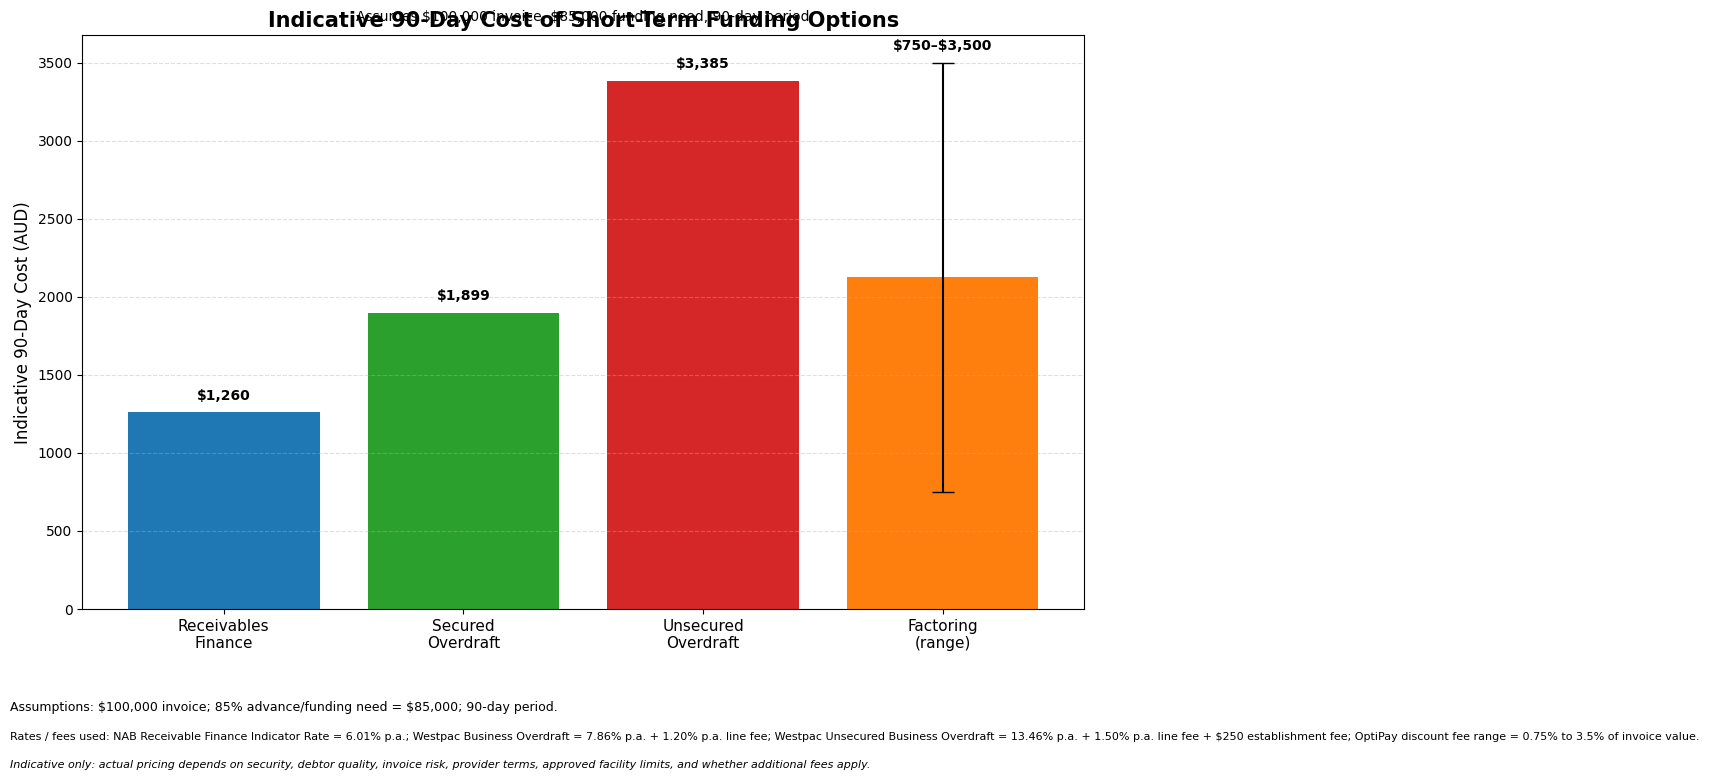

Indicative 90-day costs:
Receivables finance: $1,259.63
Secured overdraft:   $1,898.88
Unsecured overdraft: $3,385.45
Factoring range:     $750.00 to $3,500.00


In [11]:
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# assumptions
# ----------------------------
invoice_value = 100000
funding_amount = 85000
days = 90

# annual rates / fees
receivables_rate = 0.0601          # NAB Receivable Finance Indicator Rate: 6.01% p.a.
secured_overdraft_rate = 0.0786    # Westpac Business Overdraft: 7.86% p.a.
secured_line_fee = 0.0120          # Westpac Business Overdraft line fee: 1.20% p.a.

unsecured_overdraft_rate = 0.1346  # Westpac Unsecured Overdraft: 13.46% p.a.
unsecured_line_fee = 0.0150        # Westpac Unsecured Overdraft line fee: 1.50% p.a.
unsecured_est_fee = 250            # Westpac Unsecured Overdraft establishment fee: $250

# factoring fee range on invoice value
factoring_low = 0.0075 * invoice_value   # OptiPay: 0.75%
factoring_high = 0.0350 * invoice_value  # OptiPay: 3.5%

# ----------------------------
# cost calculations
# ----------------------------
receivables_cost = funding_amount * receivables_rate * days / 365

secured_overdraft_cost = (
    funding_amount * secured_overdraft_rate * days / 365
    + funding_amount * secured_line_fee * days / 365
)

unsecured_overdraft_cost = (
    funding_amount * unsecured_overdraft_rate * days / 365
    + funding_amount * unsecured_line_fee * days / 365
    + unsecured_est_fee
)

# midpoint for plotting factoring as a range bar
factoring_mid = (factoring_low + factoring_high) / 2
factoring_err = (factoring_high - factoring_low) / 2

labels = [
    "Receivables\nFinance",
    "Secured\nOverdraft",
    "Unsecured\nOverdraft",
    "Factoring\n(range)"
]

values = [
    receivables_cost,
    secured_overdraft_cost,
    unsecured_overdraft_cost,
    factoring_mid
]

colors = ["tab:blue", "tab:green", "tab:red", "tab:orange"]

# ----------------------------
# plot
# ----------------------------
fig, ax = plt.subplots(figsize=(11, 8))
x = np.arange(len(labels))

# first three normal bars
ax.bar(x[:3], values[:3], color=colors[:3])

# factoring bar with error range
ax.bar(
    x[3],
    values[3],
    color=colors[3],
    yerr=factoring_err,
    capsize=8
)

# value labels
for i in range(3):
    ax.text(
        x[i],
        values[i] + 60,
        f"\${values[i]:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# factoring range label
ax.text(
    x[3],
    values[3] + factoring_err + 60,
    f"\${factoring_low:,.0f}–\${factoring_high:,.0f}",
    ha="center",
    va="bottom",
    fontsize=10,
    fontweight="bold"
)

# chart formatting
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel("Indicative 90-Day Cost (AUD)", fontsize=12)
ax.set_title(
    "Indicative 90-Day Cost of Short-Term Funding Options",
    fontsize=15,
    fontweight="bold"
)

subtitle = (
    f"Assumes \\${invoice_value:,.0f} invoice, \\${funding_amount:,.0f} funding need, "
    f"{days}-day period"
)
ax.text(
    0.5,
    1.02,
    subtitle,
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=10
)

ax.grid(axis="y", linestyle="--", alpha=0.4)

# ----------------------------
# footnotes inside image
# ----------------------------
footnote_1 = (
    "Assumptions: \\$100,000 invoice; 85% advance/funding need = \\$85,000; 90-day period."
)

footnote_2 = (
    "Rates / fees used: NAB Receivable Finance Indicator Rate = 6.01% p.a.; "
    "Westpac Business Overdraft = 7.86% p.a. + 1.20% p.a. line fee; "
    "Westpac Unsecured Business Overdraft = 13.46% p.a. + 1.50% p.a. line fee + \\$250 establishment fee; "
    "OptiPay discount fee range = 0.75% to 3.5% of invoice value."
)

footnote_3 = (
    "Indicative only: actual pricing depends on security, debtor quality, invoice risk, provider terms, "
    "approved facility limits, and whether additional fees apply."
)

fig.text(0.01, 0.10, footnote_1, ha="left", va="bottom", fontsize=9)
fig.text(0.01, 0.065, footnote_2, ha="left", va="bottom", fontsize=8)
fig.text(0.01, 0.03, footnote_3, ha="left", va="bottom", fontsize=8, style="italic")

# leave room at bottom for notes
plt.tight_layout(rect=[0, 0.16, 1, 1])

plt.savefig("short_term_funding_costs_90_days_with_sources.png", dpi=300, bbox_inches="tight")
plt.show()

# optional exact outputs
print("Indicative 90-day costs:")
print(f"Receivables finance: ${receivables_cost:,.2f}")
print(f"Secured overdraft:   ${secured_overdraft_cost:,.2f}")
print(f"Unsecured overdraft: ${unsecured_overdraft_cost:,.2f}")
print(f"Factoring range:     ${factoring_low:,.2f} to ${factoring_high:,.2f}")

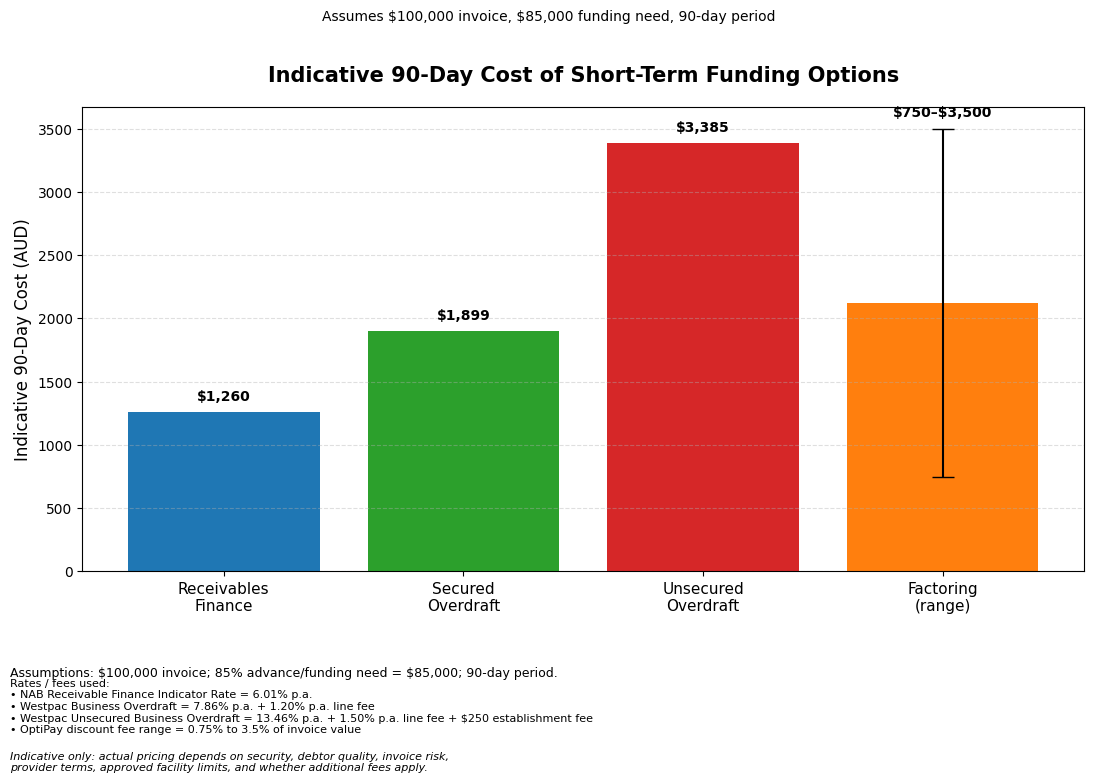

Indicative 90-day costs:
Receivables finance: $1,259.63
Secured overdraft:   $1,898.88
Unsecured overdraft: $3,385.45
Factoring range:     $750.00 to $3,500.00


In [12]:
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# assumptions
# ----------------------------
invoice_value = 100000
funding_amount = 85000
days = 90

# annual rates / fees
receivables_rate = 0.0601          # NAB Receivable Finance Indicator Rate: 6.01% p.a.
secured_overdraft_rate = 0.0786    # Westpac Business Overdraft: 7.86% p.a.
secured_line_fee = 0.0120          # Westpac Business Overdraft line fee: 1.20% p.a.

unsecured_overdraft_rate = 0.1346  # Westpac Unsecured Overdraft: 13.46% p.a.
unsecured_line_fee = 0.0150        # Westpac Unsecured Overdraft line fee: 1.50% p.a.
unsecured_est_fee = 250            # Westpac Unsecured Overdraft establishment fee: $250

# factoring fee range on invoice value
factoring_low = 0.0075 * invoice_value   # OptiPay: 0.75%
factoring_high = 0.0350 * invoice_value  # OptiPay: 3.5%

# ----------------------------
# cost calculations
# ----------------------------
receivables_cost = funding_amount * receivables_rate * days / 365

secured_overdraft_cost = (
    funding_amount * secured_overdraft_rate * days / 365
    + funding_amount * secured_line_fee * days / 365
)

unsecured_overdraft_cost = (
    funding_amount * unsecured_overdraft_rate * days / 365
    + funding_amount * unsecured_line_fee * days / 365
    + unsecured_est_fee
)

factoring_mid = (factoring_low + factoring_high) / 2
factoring_err = (factoring_high - factoring_low) / 2

labels = [
    "Receivables\nFinance",
    "Secured\nOverdraft",
    "Unsecured\nOverdraft",
    "Factoring\n(range)"
]

values = [
    receivables_cost,
    secured_overdraft_cost,
    unsecured_overdraft_cost,
    factoring_mid
]

colors = ["tab:blue", "tab:green", "tab:red", "tab:orange"]

# ----------------------------
# plot
# ----------------------------
fig, ax = plt.subplots(figsize=(11, 8.5))
x = np.arange(len(labels))

# bars
ax.bar(x[:3], values[:3], color=colors[:3])
ax.bar(
    x[3],
    values[3],
    color=colors[3],
    yerr=factoring_err,
    capsize=8
)

# value labels
for i in range(3):
    ax.text(
        x[i],
        values[i] + 70,
        f"\${values[i]:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax.text(
    x[3],
    values[3] + factoring_err + 70,
    f"\${factoring_low:,.0f}–\${factoring_high:,.0f}",
    ha="center",
    va="bottom",
    fontsize=10,
    fontweight="bold"
)

# title only
ax.set_title(
    "Indicative 90-Day Cost of Short-Term Funding Options",
    fontsize=15,
    fontweight="bold",
    pad=18
)

# move subtitle lower so it doesn't sit behind the title
fig.text(
    0.5,
    0.90,
    f"Assumes \\${invoice_value:,.0f} invoice, \\${funding_amount:,.0f} funding need, {days}-day period",
    ha="center",
    va="center",
    fontsize=10
)

# axes
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel("Indicative 90-Day Cost (AUD)", fontsize=12)
ax.grid(axis="y", linestyle="--", alpha=0.4)

# ----------------------------
# wrapped footnotes
# ----------------------------
footnote_1 = (
    "Assumptions: \\$100,000 invoice; 85% advance/funding need = \\$85,000; 90-day period."
)

footnote_2 = (
    "Rates / fees used:\n"
    "• NAB Receivable Finance Indicator Rate = 6.01% p.a.\n"
    "• Westpac Business Overdraft = 7.86% p.a. + 1.20% p.a. line fee\n"
    "• Westpac Unsecured Business Overdraft = 13.46% p.a. + 1.50% p.a. line fee + \\$250 establishment fee\n"
    "• OptiPay discount fee range = 0.75% to 3.5% of invoice value"
)

footnote_3 = (
    "Indicative only: actual pricing depends on security, debtor quality, invoice risk,\n"
    "provider terms, approved facility limits, and whether additional fees apply."
)

fig.text(0.01, 0.12, footnote_1, ha="left", va="bottom", fontsize=9)
fig.text(0.01, 0.055, footnote_2, ha="left", va="bottom", fontsize=8)
fig.text(0.01, 0.01, footnote_3, ha="left", va="bottom", fontsize=8, style="italic")

# leave room for subtitle + footnotes
plt.tight_layout(rect=[0, 0.18, 1, 0.86])

plt.savefig("short_term_funding_costs_90_days_with_sources.png", dpi=300, bbox_inches="tight")
plt.show()

print("Indicative 90-day costs:")
print(f"Receivables finance: ${receivables_cost:,.2f}")
print(f"Secured overdraft:   ${secured_overdraft_cost:,.2f}")
print(f"Unsecured overdraft: ${unsecured_overdraft_cost:,.2f}")
print(f"Factoring range:     ${factoring_low:,.2f} to ${factoring_high:,.2f}")

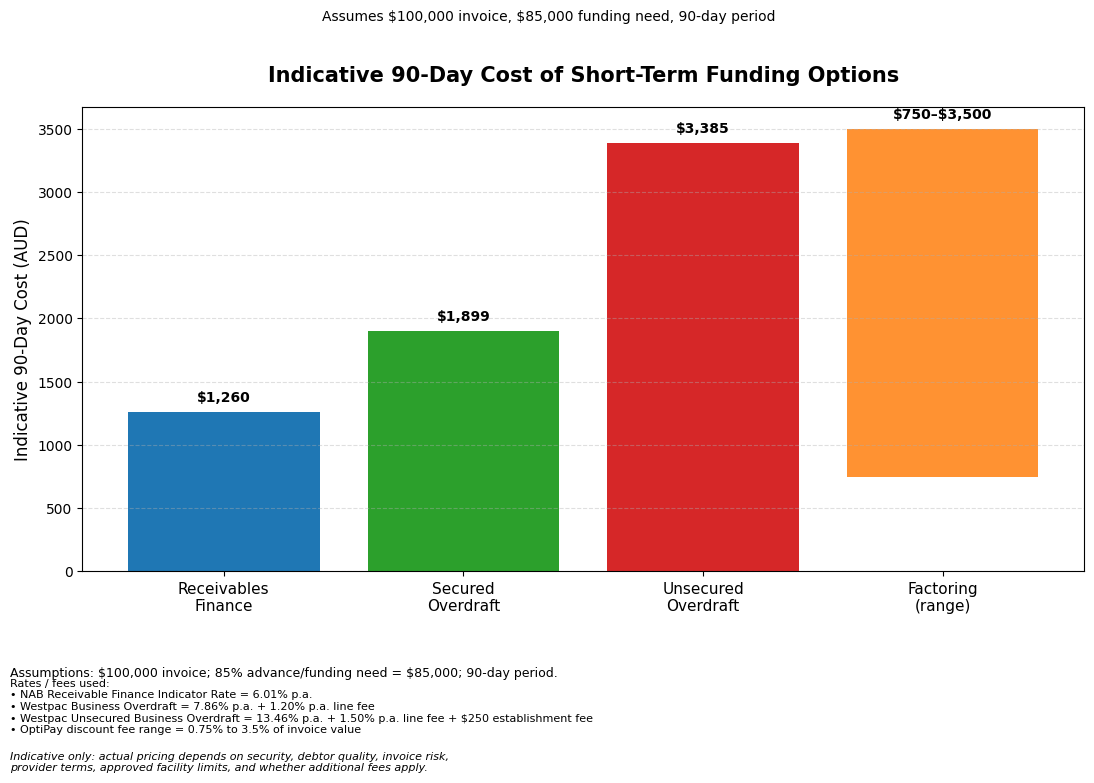

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# assumptions
# ----------------------------
invoice_value = 100000
funding_amount = 85000
days = 90

# annual rates / fees
receivables_rate = 0.0601
secured_overdraft_rate = 0.0786
secured_line_fee = 0.0120

unsecured_overdraft_rate = 0.1346
unsecured_line_fee = 0.0150
unsecured_est_fee = 250

# factoring fee range
factoring_low = 0.0075 * invoice_value
factoring_high = 0.0350 * invoice_value
factoring_height = factoring_high - factoring_low

# ----------------------------
# cost calculations
# ----------------------------
receivables_cost = funding_amount * receivables_rate * days / 365

secured_overdraft_cost = (
    funding_amount * secured_overdraft_rate * days / 365
    + funding_amount * secured_line_fee * days / 365
)

unsecured_overdraft_cost = (
    funding_amount * unsecured_overdraft_rate * days / 365
    + funding_amount * unsecured_line_fee * days / 365
    + unsecured_est_fee
)

labels = [
    "Receivables\nFinance",
    "Secured\nOverdraft",
    "Unsecured\nOverdraft",
    "Factoring\n(range)"
]

x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(11, 8.5))

# normal bars
bar_colors = ["tab:blue", "tab:green", "tab:red"]
bar_values = [receivables_cost, secured_overdraft_cost, unsecured_overdraft_cost]

ax.bar(x[:3], bar_values, color=bar_colors)

# floating range bar for factoring
ax.bar(
    x[3],
    factoring_height,
    bottom=factoring_low,
    color="tab:orange",
    alpha=0.85
)

# labels above bars
for i, value in enumerate(bar_values):
    ax.text(
        x[i],
        value + 60,
        f"\${value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# factoring labels
ax.text(
    x[3],
    factoring_high + 60,
    f"\${factoring_low:,.0f}–\${factoring_high:,.0f}",
    ha="center",
    va="bottom",
    fontsize=10,
    fontweight="bold"
)

# title
ax.set_title(
    "Indicative 90-Day Cost of Short-Term Funding Options",
    fontsize=15,
    fontweight="bold",
    pad=18
)

# subtitle
fig.text(
    0.5,
    0.90,
    f"Assumes \\${invoice_value:,.0f} invoice, \\${funding_amount:,.0f} funding need, {days}-day period",
    ha="center",
    va="center",
    fontsize=10
)

# axes
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel("Indicative 90-Day Cost (AUD)", fontsize=12)
ax.grid(axis="y", linestyle="--", alpha=0.4)

# notes
footnote_1 = (
    "Assumptions: \\$100,000 invoice; 85% advance/funding need = \\$85,000; 90-day period."
)

footnote_2 = (
    "Rates / fees used:\n"
    "• NAB Receivable Finance Indicator Rate = 6.01% p.a.\n"
    "• Westpac Business Overdraft = 7.86% p.a. + 1.20% p.a. line fee\n"
    "• Westpac Unsecured Business Overdraft = 13.46% p.a. + 1.50% p.a. line fee + \\$250 establishment fee\n"
    "• OptiPay discount fee range = 0.75% to 3.5% of invoice value"
)

footnote_3 = (
    "Indicative only: actual pricing depends on security, debtor quality, invoice risk,\n"
    "provider terms, approved facility limits, and whether additional fees apply."
)

fig.text(0.01, 0.12, footnote_1, ha="left", va="bottom", fontsize=9)
fig.text(0.01, 0.055, footnote_2, ha="left", va="bottom", fontsize=8)
fig.text(0.01, 0.01, footnote_3, ha="left", va="bottom", fontsize=8, style="italic")

plt.tight_layout(rect=[0, 0.18, 1, 0.86])
plt.savefig("short_term_funding_costs_90_days_floating_factoring.png", dpi=300, bbox_inches="tight")
plt.show()

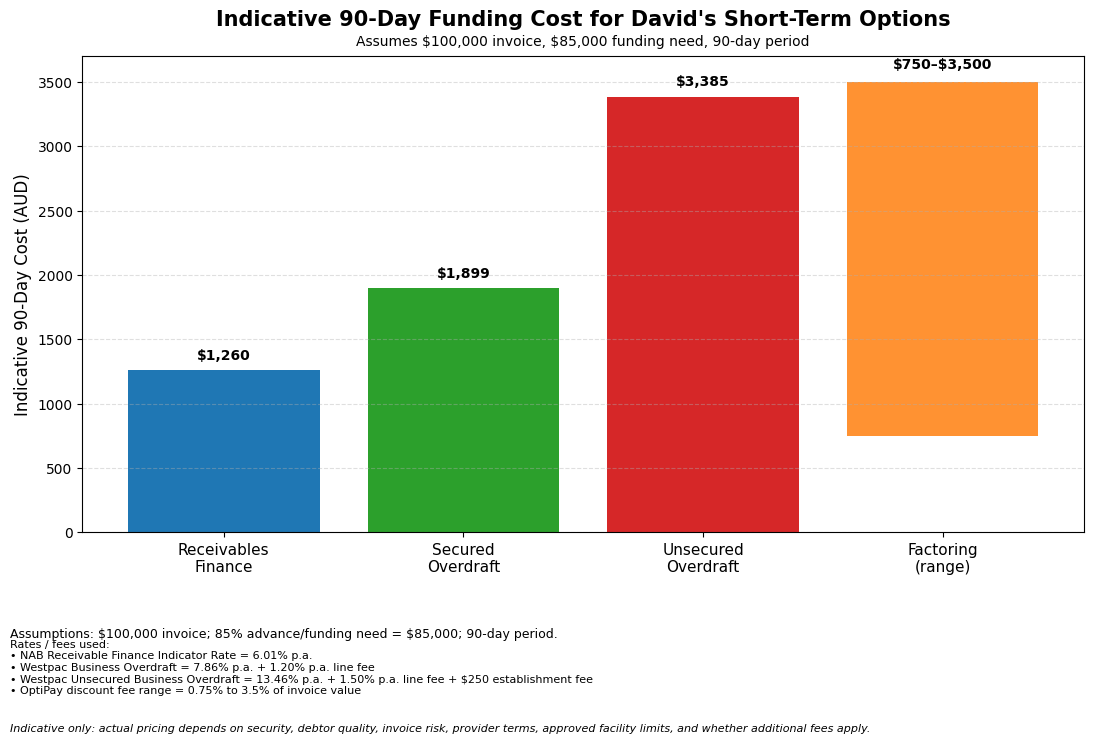

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# assumptions
# ----------------------------
invoice_value = 100000
funding_amount = 85000
days = 90

# annual rates / fees
receivables_rate = 0.0601
secured_overdraft_rate = 0.0786
secured_line_fee = 0.0120

unsecured_overdraft_rate = 0.1346
unsecured_line_fee = 0.0150
unsecured_est_fee = 250

# factoring fee range
factoring_low = 0.0075 * invoice_value
factoring_high = 0.0350 * invoice_value
factoring_height = factoring_high - factoring_low

# ----------------------------
# cost calculations
# ----------------------------
receivables_cost = funding_amount * receivables_rate * days / 365

secured_overdraft_cost = (
    funding_amount * secured_overdraft_rate * days / 365
    + funding_amount * secured_line_fee * days / 365
)

unsecured_overdraft_cost = (
    funding_amount * unsecured_overdraft_rate * days / 365
    + funding_amount * unsecured_line_fee * days / 365
    + unsecured_est_fee
)

labels = [
    "Receivables\nFinance",
    "Secured\nOverdraft",
    "Unsecured\nOverdraft",
    "Factoring\n(range)"
]

x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(11, 8.5))

# normal bars
bar_colors = ["tab:blue", "tab:green", "tab:red"]
bar_values = [receivables_cost, secured_overdraft_cost, unsecured_overdraft_cost]

ax.bar(x[:3], bar_values, color=bar_colors)

# floating range bar for factoring
ax.bar(
    x[3],
    factoring_height,
    bottom=factoring_low,
    color="tab:orange",
    alpha=0.85
)

# labels above bars
for i, value in enumerate(bar_values):
    ax.text(
        x[i],
        value + 60,
        f"\${value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# factoring range label
ax.text(
    x[3],
    factoring_high + 80,
    f"\${factoring_low:,.0f}–\${factoring_high:,.0f}",
    ha="center",
    va="bottom",
    fontsize=10,
    fontweight="bold"
)

# title
ax.set_title(
    "Indicative 90-Day Funding Cost for David's Short-Term Options",
    fontsize=15,
    fontweight="bold",
    pad=22
)

# subtitle under title
ax.text(
    0.5,
    1.015,
    f"Assumes \\${invoice_value:,.0f} invoice, \\${funding_amount:,.0f} funding need, {days}-day period",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=10
)

# axes
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel("Indicative 90-Day Cost (AUD)", fontsize=12)
ax.set_ylim(0, 3700)
ax.grid(axis="y", linestyle="--", alpha=0.4)

# wrapped footnotes
footnote_1 = (
    "Assumptions: \\$100,000 invoice; 85% advance/funding need = \\$85,000; 90-day period."
)

footnote_2 = (
    "Rates / fees used:\n"
    "• NAB Receivable Finance Indicator Rate = 6.01% p.a.\n"
    "• Westpac Business Overdraft = 7.86% p.a. + 1.20% p.a. line fee\n"
    "• Westpac Unsecured Business Overdraft = 13.46% p.a. + 1.50% p.a. line fee + \\$250 establishment fee\n"
    "• OptiPay discount fee range = 0.75% to 3.5% of invoice value"
)

footnote_3 = (
    "Indicative only: actual pricing depends on security, debtor quality, invoice risk, provider terms, approved facility limits, and whether additional fees apply."
)

fig.text(0.01, 0.12, footnote_1, ha="left", va="bottom", fontsize=9)
fig.text(0.01, 0.055, footnote_2, ha="left", va="bottom", fontsize=8)
fig.text(0.01, 0.01, footnote_3, ha="left", va="bottom", fontsize=8, style="italic")

plt.tight_layout(rect=[0, 0.18, 1, 0.88])

plt.savefig("short_term_funding_costs_90_days_floating_factoring.png", dpi=300, bbox_inches="tight")
plt.show()

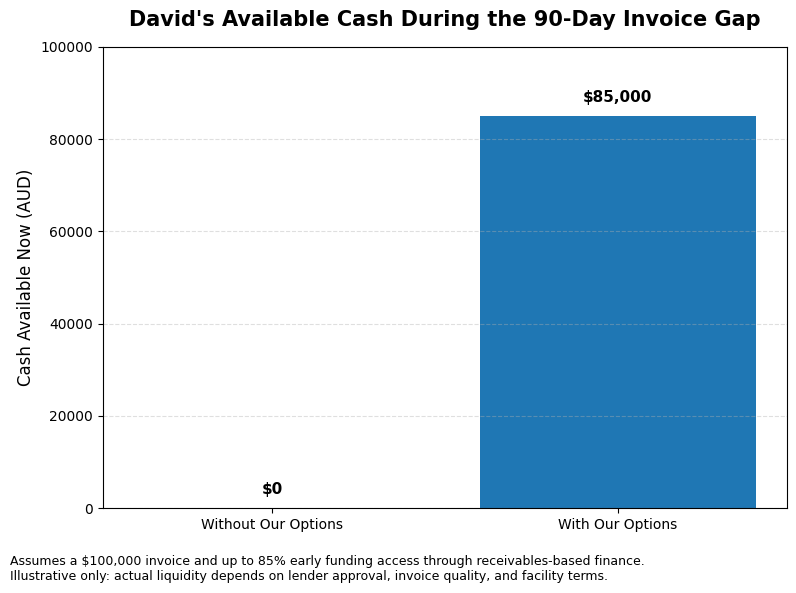

In [22]:
import matplotlib.pyplot as plt

# ----------------------------
# assumptions
# ----------------------------
invoice_value = 100000
available_cash_without = 0
available_cash_with = 85000   # based on 85% advance assumption

labels = ["Without Our Options", "With Our Options"]
values = [available_cash_without, available_cash_with]

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(labels, values)

# title and labels
ax.set_title(
    "David's Available Cash During the 90-Day Invoice Gap",
    fontsize=15,
    fontweight="bold",
    pad=15
)
ax.set_ylabel("Cash Available Now (AUD)", fontsize=12)
ax.set_ylim(0, 100000)
ax.grid(axis="y", linestyle="--", alpha=0.4)

# value labels
for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 2500,
        f"${value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# note under chart
fig.text(
    0.01,
    0.02,
    "Assumes a $100,000 invoice and up to 85% early funding access through receivables-based finance.\n"
    "Illustrative only: actual liquidity depends on lender approval, invoice quality, and facility terms.",
    ha="left",
    va="bottom",
    fontsize=9
)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig("david_cash_with_vs_without_options.png", dpi=300, bbox_inches="tight")
plt.show()

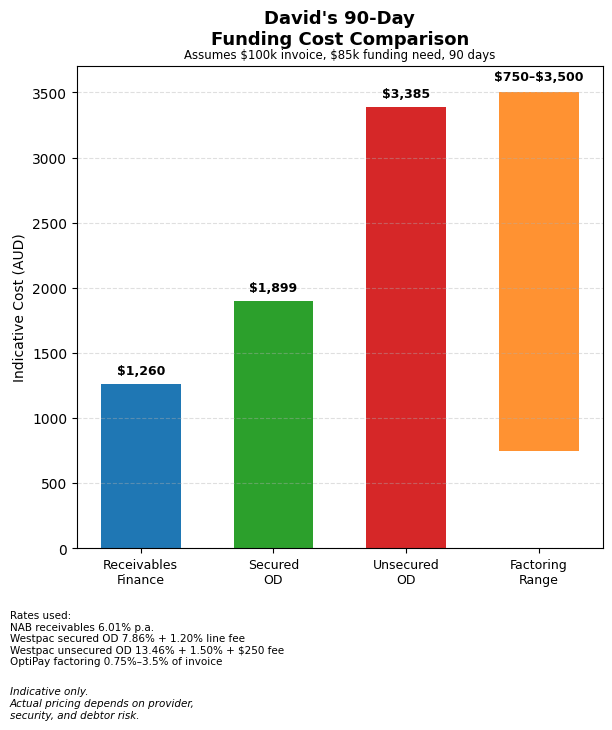

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# assumptions
# ----------------------------
invoice_value = 100000
funding_amount = 85000
days = 90

# annual rates / fees
receivables_rate = 0.0601
secured_overdraft_rate = 0.0786
secured_line_fee = 0.0120

unsecured_overdraft_rate = 0.1346
unsecured_line_fee = 0.0150
unsecured_est_fee = 250

# factoring fee range
factoring_low = 0.0075 * invoice_value
factoring_high = 0.0350 * invoice_value
factoring_height = factoring_high - factoring_low

# ----------------------------
# cost calculations
# ----------------------------
receivables_cost = funding_amount * receivables_rate * days / 365

secured_overdraft_cost = (
    funding_amount * secured_overdraft_rate * days / 365
    + funding_amount * secured_line_fee * days / 365
)

unsecured_overdraft_cost = (
    funding_amount * unsecured_overdraft_rate * days / 365
    + funding_amount * unsecured_line_fee * days / 365
    + unsecured_est_fee
)

labels = [
    "Receivables\nFinance",
    "Secured\nOD",
    "Unsecured\nOD",
    "Factoring\nRange"
]

x = np.arange(len(labels))

# narrower figure
fig, ax = plt.subplots(figsize=(6.2, 8.2))

# normal bars
bar_colors = ["tab:blue", "tab:green", "tab:red"]
bar_values = [receivables_cost, secured_overdraft_cost, unsecured_overdraft_cost]

ax.bar(x[:3], bar_values, color=bar_colors, width=0.6)

# floating range bar for factoring
ax.bar(
    x[3],
    factoring_height,
    bottom=factoring_low,
    color="tab:orange",
    alpha=0.85,
    width=0.6
)

# labels above bars
for i, value in enumerate(bar_values):
    ax.text(
        x[i],
        value + 55,
        f"\${value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

# factoring label
ax.text(
    x[3],
    factoring_high + 70,
    f"\${factoring_low:,.0f}–\${factoring_high:,.0f}",
    ha="center",
    va="bottom",
    fontsize=9,
    fontweight="bold"
)

# title
ax.set_title(
    "David's 90-Day\nFunding Cost Comparison",
    fontsize=13,
    fontweight="bold",
    pad=16
)

# subtitle under title
ax.text(
    0.5,
    1.01,
    "Assumes \$100k invoice, \$85k funding need, 90 days",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=8.5
)

# axes
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("Indicative Cost (AUD)", fontsize=10)
ax.set_ylim(0, 3700)
ax.grid(axis="y", linestyle="--", alpha=0.4)

# short wrapped footnotes
footnote_1 = (
    "Rates used:\n"
    "NAB receivables 6.01% p.a.\n"
    "Westpac secured OD 7.86% + 1.20% line fee\n"
    "Westpac unsecured OD 13.46% + 1.50% + \$250 fee\n"
    "OptiPay factoring 0.75%–3.5% of invoice"
)

footnote_2 = (
    "Indicative only.\n"
    "Actual pricing depends on provider,\n"
    "security, and debtor risk."
)

fig.text(0.02, 0.08, footnote_1, ha="left", va="bottom", fontsize=7.5)
fig.text(0.02, 0.015, footnote_2, ha="left", va="bottom", fontsize=7.5, style="italic")

plt.tight_layout(rect=[0, 0.16, 1, 0.90])

plt.savefig("short_term_funding_costs_narrow.png", dpi=300, bbox_inches="tight")
plt.show()

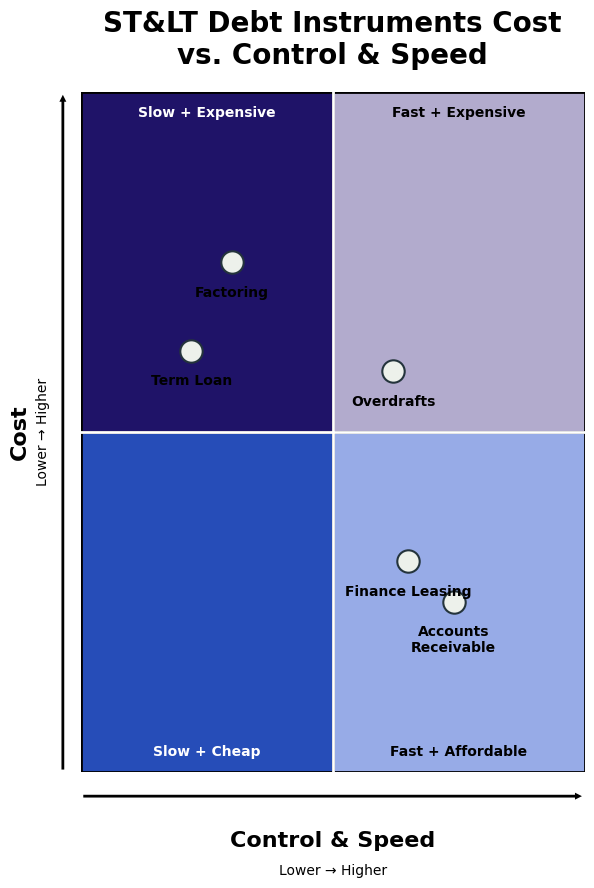

In [24]:
import matplotlib.pyplot as plt

# ----------------------------
# data
# x = control & speed
# y = cost
# ----------------------------
labels = [
    "Factoring",
    "Term Loan",
    "Overdrafts",
    "Finance Leasing",
    "Accounts\nReceivable"
]

x = [3.0, 2.2, 6.2, 6.5, 7.4]
y = [7.5, 6.2, 5.9, 3.1, 2.5]

# ----------------------------
# figure
# ----------------------------
fig, ax = plt.subplots(figsize=(6, 9))

ax.set_xlim(0, 10)
ax.set_ylim(0, 10)

# remove default spines/ticks
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks([])
ax.set_yticks([])

# ----------------------------
# quadrant backgrounds
# ----------------------------
# top-left
ax.add_patch(plt.Rectangle((0, 5), 5, 5, facecolor="#1f1368", edgecolor="black", linewidth=2))
# top-right
ax.add_patch(plt.Rectangle((5, 5), 5, 5, facecolor="#b2abcd", edgecolor="black", linewidth=2))
# bottom-left
ax.add_patch(plt.Rectangle((0, 0), 5, 5, facecolor="#264db8", edgecolor="black", linewidth=2))
# bottom-right
ax.add_patch(plt.Rectangle((5, 0), 5, 5, facecolor="#97abe7", edgecolor="black", linewidth=2))

# quadrant divider lines
ax.plot([5, 5], [0, 10], color="white", linewidth=2)
ax.plot([0, 10], [5, 5], color="white", linewidth=2)

# ----------------------------
# scatter points
# ----------------------------
ax.scatter(x, y, s=260, facecolor="#edf1eb", edgecolor="#24343c", linewidth=1.5, zorder=3)

# labels
offsets = {
    "Factoring": (0, -0.45),
    "Term Loan": (0, -0.45),
    "Overdrafts": (0, -0.45),
    "Finance Leasing": (0, -0.45),
    "Accounts\nReceivable": (0, -0.55)
}

for xi, yi, label in zip(x, y, labels):
    dx, dy = offsets[label]
    ax.text(
        xi + dx,
        yi + dy,
        label,
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="black"
    )

# ----------------------------
# title
# ----------------------------
ax.set_title(
    "ST&LT Debt Instruments Cost\nvs. Control & Speed",
    fontsize=20,
    fontweight="bold",
    pad=20
)

# quadrant text
ax.text(2.5, 9.7, "Slow + Expensive", ha="center", va="center", fontsize=10, fontweight="bold", color="white")
ax.text(7.5, 9.7, "Fast + Expensive", ha="center", va="center", fontsize=10, fontweight="bold", color="black")
ax.text(2.5, 0.3, "Slow + Cheap", ha="center", va="center", fontsize=10, fontweight="bold", color="white")
ax.text(7.5, 0.3, "Fast + Affordable", ha="center", va="center", fontsize=10, fontweight="bold", color="black")

# ----------------------------
# custom axis arrows
# ----------------------------
ax.annotate(
    "", xy=(10, -0.35), xytext=(0, -0.35),
    arrowprops=dict(arrowstyle="simple", color="black", lw=0),
    annotation_clip=False
)

ax.annotate(
    "", xy=(-0.35, 10), xytext=(-0.35, 0),
    arrowprops=dict(arrowstyle="simple", color="black", lw=0),
    annotation_clip=False
)

# axis labels
ax.text(5, -1.0, "Control & Speed", ha="center", va="center", fontsize=16, fontweight="bold")
ax.text(5, -1.45, "Lower → Higher", ha="center", va="center", fontsize=10)

ax.text(-1.2, 5, "Cost", ha="center", va="center", rotation=90, fontsize=16, fontweight="bold")
ax.text(-0.75, 5, "Lower → Higher", ha="center", va="center", rotation=90, fontsize=10)

plt.tight_layout()
plt.savefig("narrow_debt_instruments_quadrant.png", dpi=300, bbox_inches="tight")
plt.show()

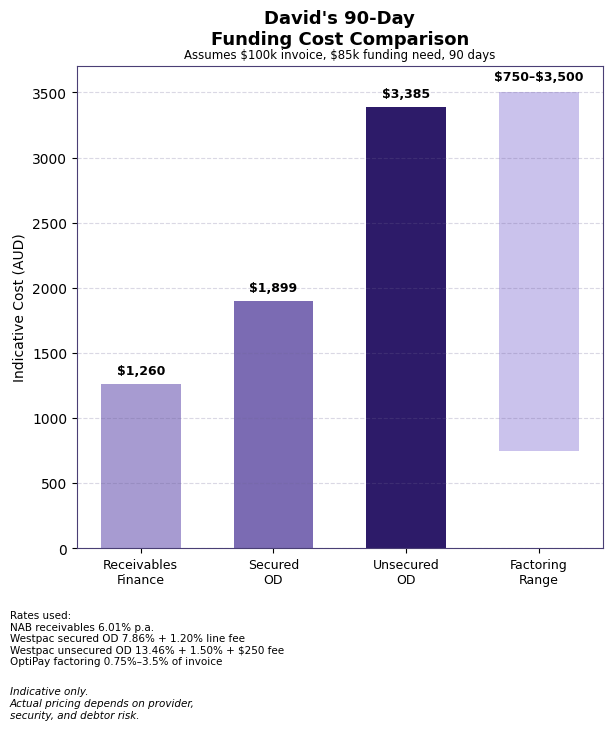

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# assumptions
# ----------------------------
invoice_value = 100000
funding_amount = 85000
days = 90

# annual rates / fees
receivables_rate = 0.0601
secured_overdraft_rate = 0.0786
secured_line_fee = 0.0120

unsecured_overdraft_rate = 0.1346
unsecured_line_fee = 0.0150
unsecured_est_fee = 250

# factoring fee range
factoring_low = 0.0075 * invoice_value
factoring_high = 0.0350 * invoice_value
factoring_height = factoring_high - factoring_low

# ----------------------------
# cost calculations
# ----------------------------
receivables_cost = funding_amount * receivables_rate * days / 365

secured_overdraft_cost = (
    funding_amount * secured_overdraft_rate * days / 365
    + funding_amount * secured_line_fee * days / 365
)

unsecured_overdraft_cost = (
    funding_amount * unsecured_overdraft_rate * days / 365
    + funding_amount * unsecured_line_fee * days / 365
    + unsecured_est_fee
)

labels = [
    "Receivables\nFinance",
    "Secured\nOD",
    "Unsecured\nOD",
    "Factoring\nRange"
]

x = np.arange(len(labels))

# ----------------------------
# figure
# ----------------------------
fig, ax = plt.subplots(figsize=(6.2, 8.2))

# background
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# purple-ish colours
bar_colors = ["#a79bd1", "#7b6bb3", "#2d1b69"]
factoring_color = "#c7bfeb"

bar_values = [receivables_cost, secured_overdraft_cost, unsecured_overdraft_cost]

# normal bars
ax.bar(x[:3], bar_values, color=bar_colors, width=0.6)

# floating range bar for factoring
ax.bar(
    x[3],
    factoring_height,
    bottom=factoring_low,
    color=factoring_color,
    alpha=0.95,
    width=0.6
)

# ----------------------------
# labels above bars
# ----------------------------
for i, value in enumerate(bar_values):
    ax.text(
        x[i],
        value + 55,
        f"\${value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="black"
    )

ax.text(
    x[3],
    factoring_high + 70,
    f"\${factoring_low:,.0f}–\${factoring_high:,.0f}",
    ha="center",
    va="bottom",
    fontsize=9,
    fontweight="bold",
    color="black"
)

# ----------------------------
# title
# ----------------------------
ax.set_title(
    "David's 90-Day\nFunding Cost Comparison",
    fontsize=13,
    fontweight="bold",
    pad=16,
    color="black"
)

# subtitle under title
ax.text(
    0.5,
    1.01,
    "Assumes \$100k invoice, \$85k funding need, 90 days",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=8.5,
    color="black"
)

# ----------------------------
# axes
# ----------------------------
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9, color="black")
ax.set_ylabel("Indicative Cost (AUD)", fontsize=10, color="black")
ax.set_ylim(0, 3700)

# soften grid
ax.grid(axis="y", linestyle="--", alpha=0.25, color="#6f6594")

# darker axis lines
for spine in ax.spines.values():
    spine.set_color("#4a3f75")

ax.tick_params(axis='y', colors='black')
ax.tick_params(axis='x', colors='black')

# ----------------------------
# short wrapped footnotes
# ----------------------------
footnote_1 = (
    "Rates used:\n"
    "NAB receivables 6.01% p.a.\n"
    "Westpac secured OD 7.86% + 1.20% line fee\n"
    "Westpac unsecured OD 13.46% + 1.50% + \$250 fee\n"
    "OptiPay factoring 0.75%–3.5% of invoice"
)

footnote_2 = (
    "Indicative only.\n"
    "Actual pricing depends on provider,\n"
    "security, and debtor risk."
)

fig.text(0.02, 0.08, footnote_1, ha="left", va="bottom", fontsize=7.5, color="black")
fig.text(0.02, 0.015, footnote_2, ha="left", va="bottom", fontsize=7.5, style="italic", color="black")

plt.tight_layout(rect=[0, 0.16, 1, 0.90])

plt.savefig("short_term_funding_costs_narrow_purple.png", dpi=300, bbox_inches="tight")
plt.show()

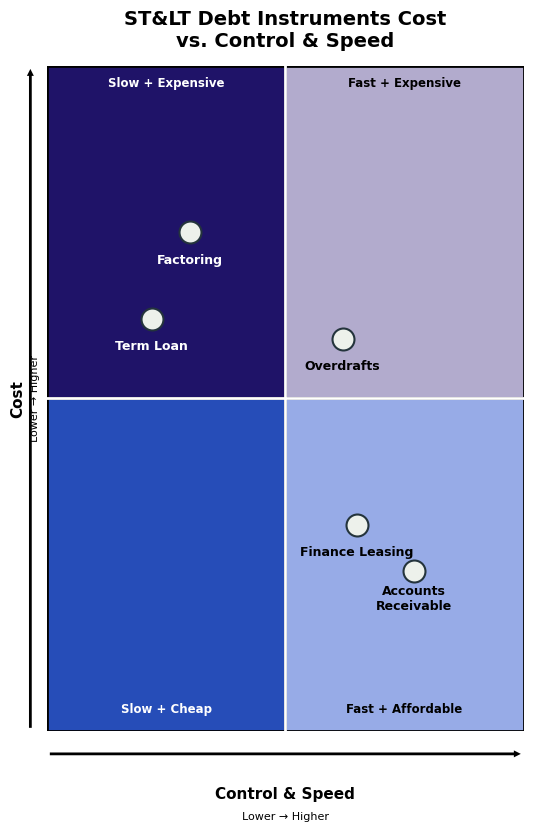

In [28]:
import matplotlib.pyplot as plt

# ----------------------------
# data
# x = control & speed
# y = cost
# ----------------------------
labels = [
    "Factoring",
    "Term Loan",
    "Overdrafts",
    "Finance Leasing",
    "Accounts\nReceivable"
]

x = [3.0, 2.2, 6.2, 6.5, 7.7]
y = [7.5, 6.2, 5.9, 3.1, 2.4]

# ----------------------------
# figure
# ----------------------------
fig, ax = plt.subplots(figsize=(5.4, 8.4))

# white background like the other plot
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

ax.set_xlim(0, 10)
ax.set_ylim(0, 10)

# remove default spines/ticks
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks([])
ax.set_yticks([])

# ----------------------------
# quadrant backgrounds
# ----------------------------
ax.add_patch(plt.Rectangle((0, 5), 5, 5, facecolor="#1f1368", edgecolor="black", linewidth=2))
ax.add_patch(plt.Rectangle((5, 5), 5, 5, facecolor="#b2abcd", edgecolor="black", linewidth=2))
ax.add_patch(plt.Rectangle((0, 0), 5, 5, facecolor="#264db8", edgecolor="black", linewidth=2))
ax.add_patch(plt.Rectangle((5, 0), 5, 5, facecolor="#97abe7", edgecolor="black", linewidth=2))

# divider lines
ax.plot([5, 5], [0, 10], color="white", linewidth=2)
ax.plot([0, 10], [5, 5], color="white", linewidth=2)

# ----------------------------
# scatter points
# ----------------------------
ax.scatter(
    x, y,
    s=250,
    facecolor="#edf1eb",
    edgecolor="#24343c",
    linewidth=1.5,
    zorder=3
)

# labels
for xi, yi, label in zip(x, y, labels):
    ax.text(
        xi,
        yi - 0.42,
        label,
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="white" if yi > 5 and xi < 5 else "black"
    )

# ----------------------------
# title
# ----------------------------
ax.set_title(
    "ST&LT Debt Instruments Cost\nvs. Control & Speed",
    fontsize=14,
    fontweight="bold",
    pad=14,
    color="black"
)

# quadrant text
ax.text(2.5, 9.75, "Slow + Expensive", ha="center", va="center",
        fontsize=8.5, fontweight="bold", color="white")
ax.text(7.5, 9.75, "Fast + Expensive", ha="center", va="center",
        fontsize=8.5, fontweight="bold", color="black")
ax.text(2.5, 0.32, "Slow + Cheap", ha="center", va="center",
        fontsize=8.5, fontweight="bold", color="white")
ax.text(7.5, 0.32, "Fast + Affordable", ha="center", va="center",
        fontsize=8.5, fontweight="bold", color="black")

# ----------------------------
# custom axis arrows
# ----------------------------
ax.annotate(
    "", xy=(10, -0.35), xytext=(0, -0.35),
    arrowprops=dict(arrowstyle="simple", color="black", lw=0),
    annotation_clip=False
)

ax.annotate(
    "", xy=(-0.35, 10), xytext=(-0.35, 0),
    arrowprops=dict(arrowstyle="simple", color="black", lw=0),
    annotation_clip=False
)

# axis labels
ax.text(5, -0.95, "Control & Speed", ha="center", va="center",
        fontsize=11, fontweight="bold", color="black")
ax.text(5, -1.30, "Lower → Higher", ha="center", va="center",
        fontsize=8, color="black")

ax.text(-0.62, 5, "Cost", ha="center", va="center",
        rotation=90, fontsize=11, fontweight="bold", color="black")
ax.text(-0.25, 5, "Lower → Higher", ha="center", va="center",
        rotation=90, fontsize=8, color="black")

plt.tight_layout()
plt.savefig("narrow_quadrant_chart_matching_font.png", dpi=300, bbox_inches="tight")
plt.show()

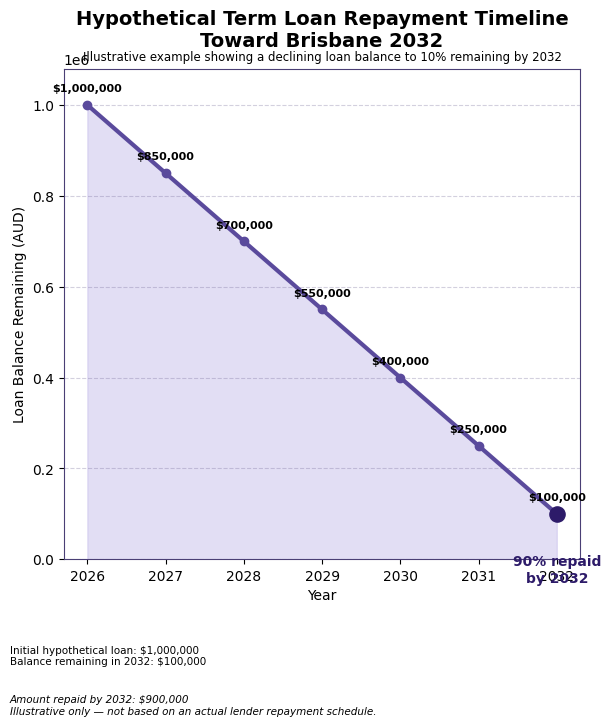

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# hypothetical term loan setup
# ----------------------------
start_year = 2026
end_year = 2032
years = np.arange(start_year, end_year + 1)

initial_loan = 1000000   # hypothetical $1,000,000 term loan
percent_remaining_2032 = 0.10   # 10% remaining by 2032 = 90% repaid

# create a simple straight-line decline to 10% by 2032
loan_balance = np.linspace(
    initial_loan,
    initial_loan * percent_remaining_2032,
    len(years)
)

amount_repaid_by_2032 = initial_loan - loan_balance[-1]

# ----------------------------
# plot
# ----------------------------
fig, ax = plt.subplots(figsize=(6.2, 8.2))

# white background
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# line
ax.plot(
    years,
    loan_balance,
    marker="o",
    linewidth=3,
    color="#5a4a9c"
)

# fill under line
ax.fill_between(
    years,
    loan_balance,
    color="#c7bfeb",
    alpha=0.5
)

# value labels
for x, y in zip(years, loan_balance):
    ax.text(
        x,
        y + 25000,
        f"${y:,.0f}",
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold"
    )

# highlight 2032 point
ax.scatter(
    years[-1],
    loan_balance[-1],
    s=120,
    color="#2d1b69",
    zorder=3
)

ax.text(
    years[-1],
    loan_balance[-1] - 90000,
    "90% repaid\nby 2032",
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold",
    color="#2d1b69"
)

# titles
ax.set_title(
    "Hypothetical Term Loan Repayment Timeline\nToward Brisbane 2032",
    fontsize=14,
    fontweight="bold",
    pad=16
)

ax.text(
    0.5,
    1.01,
    "Illustrative example showing a declining loan balance to 10% remaining by 2032",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=8.5
)

# axes
ax.set_xlabel("Year", fontsize=10)
ax.set_ylabel("Loan Balance Remaining (AUD)", fontsize=10)
ax.set_xticks(years)
ax.set_ylim(0, initial_loan * 1.08)

# grid / spines
ax.grid(axis="y", linestyle="--", alpha=0.3, color="#6f6594")
for spine in ax.spines.values():
    spine.set_color("#4a3f75")

# notes
footnote_1 = (
    f"Initial hypothetical loan: ${initial_loan:,.0f}\n"
    f"Balance remaining in 2032: ${loan_balance[-1]:,.0f}"
)

footnote_2 = (
    f"Amount repaid by 2032: ${amount_repaid_by_2032:,.0f}\n"
    "Illustrative only — not based on an actual lender repayment schedule."
)

fig.text(0.02, 0.08, footnote_1, ha="left", va="bottom", fontsize=7.5, color="black")
fig.text(0.02, 0.02, footnote_2, ha="left", va="bottom", fontsize=7.5, style="italic", color="black")

plt.tight_layout(rect=[0, 0.14, 1, 0.90])

plt.savefig("term_loan_olympics_timeline.png", dpi=300, bbox_inches="tight")
plt.show()

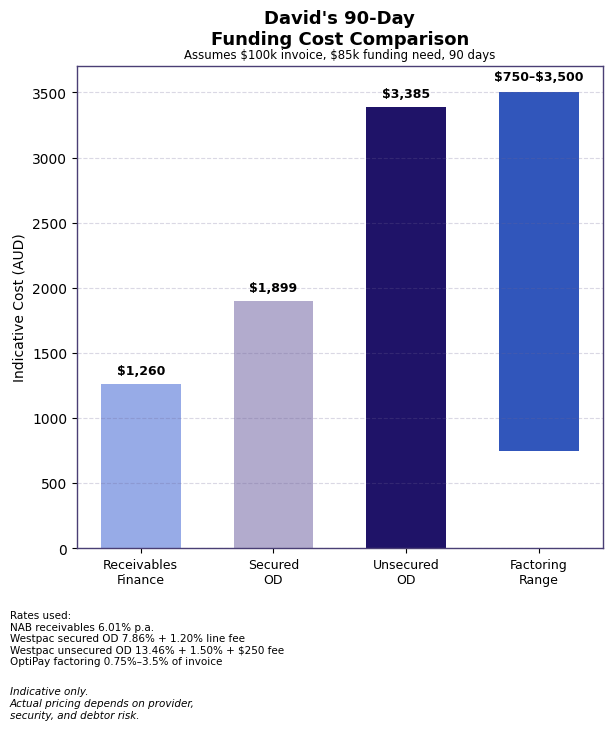

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# assumptions
# ----------------------------
invoice_value = 100000
funding_amount = 85000
days = 90

# annual rates / fees
receivables_rate = 0.0601
secured_overdraft_rate = 0.0786
secured_line_fee = 0.0120

unsecured_overdraft_rate = 0.1346
unsecured_line_fee = 0.0150
unsecured_est_fee = 250

# factoring fee range
factoring_low = 0.0075 * invoice_value
factoring_high = 0.0350 * invoice_value
factoring_height = factoring_high - factoring_low

# ----------------------------
# cost calculations
# ----------------------------
receivables_cost = funding_amount * receivables_rate * days / 365

secured_overdraft_cost = (
    funding_amount * secured_overdraft_rate * days / 365
    + funding_amount * secured_line_fee * days / 365
)

unsecured_overdraft_cost = (
    funding_amount * unsecured_overdraft_rate * days / 365
    + funding_amount * unsecured_line_fee * days / 365
    + unsecured_est_fee
)

labels = [
    "Receivables\nFinance",
    "Secured\nOD",
    "Unsecured\nOD",
    "Factoring\nRange"
]

x = np.arange(len(labels))

# ----------------------------
# figure
# ----------------------------
fig, ax = plt.subplots(figsize=(6.2, 8.2))

# white background
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# colours matched to your quadrant chart
bar_colors = [
    "#97abe7",  # light blue-purple
    "#b2abcd",  # light purple-grey
    "#1f1368"   # dark purple
]
factoring_color = "#264db8"  # strong blue-purple

bar_values = [receivables_cost, secured_overdraft_cost, unsecured_overdraft_cost]

# normal bars
ax.bar(x[:3], bar_values, color=bar_colors, width=0.6)

# floating range bar for factoring
ax.bar(
    x[3],
    factoring_height,
    bottom=factoring_low,
    color=factoring_color,
    alpha=0.95,
    width=0.6
)

# ----------------------------
# labels above bars
# ----------------------------
for i, value in enumerate(bar_values):
    ax.text(
        x[i],
        value + 55,
        f"\${value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="black"
    )

ax.text(
    x[3],
    factoring_high + 70,
    f"\${factoring_low:,.0f}–\${factoring_high:,.0f}",
    ha="center",
    va="bottom",
    fontsize=9,
    fontweight="bold",
    color="black"
)

# ----------------------------
# title
# ----------------------------
ax.set_title(
    "David's 90-Day\nFunding Cost Comparison",
    fontsize=13,
    fontweight="bold",
    pad=16
)

# subtitle under title
ax.text(
    0.5,
    1.01,
    "Assumes \$100k invoice, \$85k funding need, 90 days",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=8.5
)

# ----------------------------
# axes
# ----------------------------
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("Indicative Cost (AUD)", fontsize=10)
ax.set_ylim(0, 3700)

# purple grid / borders
ax.grid(axis="y", linestyle="--", alpha=0.25, color="#6f6594")

for spine in ax.spines.values():
    spine.set_color("#4a3f75")
    spine.set_linewidth(1.0)

ax.tick_params(axis='y', colors='black')
ax.tick_params(axis='x', colors='black')

# ----------------------------
# short wrapped footnotes
# ----------------------------
footnote_1 = (
    "Rates used:\n"
    "NAB receivables 6.01% p.a.\n"
    "Westpac secured OD 7.86% + 1.20% line fee\n"
    "Westpac unsecured OD 13.46% + 1.50% + \$250 fee\n"
    "OptiPay factoring 0.75%–3.5% of invoice"
)

footnote_2 = (
    "Indicative only.\n"
    "Actual pricing depends on provider,\n"
    "security, and debtor risk."
)

fig.text(0.02, 0.08, footnote_1, ha="left", va="bottom", fontsize=7.5, color="black")
fig.text(0.02, 0.015, footnote_2, ha="left", va="bottom", fontsize=7.5, style="italic", color="black")

plt.tight_layout(rect=[0, 0.16, 1, 0.90])

plt.savefig("short_term_funding_costs_narrow_purple_match.png", dpi=300, bbox_inches="tight")
plt.show()

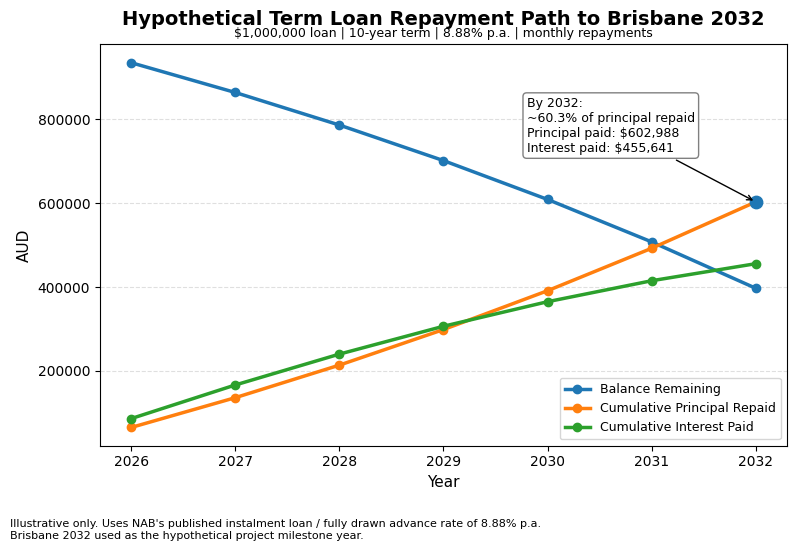

Monthly repayment: $12,602.73
Balance remaining in 2032: $397,012.34
Cumulative principal repaid by 2032: $602,987.66
Cumulative interest paid by 2032: $455,641.25
Percentage of principal repaid by 2032: 60.30%


In [31]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ----------------------------
# assumptions
# ----------------------------
loan_amount = 1_000_000          # hypothetical term loan
annual_rate = 0.0888             # NAB instalment loan / fully drawn advance rate
loan_term_years = 10             # 10-year term
start_year = 2026
end_year = 2032

# ----------------------------
# loan maths
# ----------------------------
monthly_rate = annual_rate / 12
n_payments = loan_term_years * 12

# standard amortising monthly repayment
monthly_payment = loan_amount * (
    monthly_rate * (1 + monthly_rate) ** n_payments
) / (
    (1 + monthly_rate) ** n_payments - 1
)

# build amortisation schedule
balance = loan_amount
rows = []

for month in range(1, n_payments + 1):
    interest = balance * monthly_rate
    principal = monthly_payment - interest
    balance -= principal

    if balance < 0:
        principal += balance
        balance = 0

    rows.append({
        "month": month,
        "year": start_year + (month - 1) // 12,
        "interest_paid": interest,
        "principal_paid": principal,
        "balance_remaining": balance
    })

schedule = pd.DataFrame(rows)

# annual summary to 2032
annual = schedule[schedule["year"] <= end_year].groupby("year", as_index=False).agg({
    "interest_paid": "sum",
    "principal_paid": "sum",
    "balance_remaining": "last"
})

annual["cumulative_interest"] = annual["interest_paid"].cumsum()
annual["cumulative_principal"] = annual["principal_paid"].cumsum()

# 2032 summary
bal_2032 = annual.loc[annual["year"] == end_year, "balance_remaining"].iloc[0]
principal_2032 = annual.loc[annual["year"] == end_year, "cumulative_principal"].iloc[0]
interest_2032 = annual.loc[annual["year"] == end_year, "cumulative_interest"].iloc[0]
pct_principal_repaid = principal_2032 / loan_amount * 100

# ----------------------------
# plot
# ----------------------------
fig, ax = plt.subplots(figsize=(8, 6))

years = annual["year"]

# lines
ax.plot(years, annual["balance_remaining"], marker="o", linewidth=2.5, label="Balance Remaining")
ax.plot(years, annual["cumulative_principal"], marker="o", linewidth=2.5, label="Cumulative Principal Repaid")
ax.plot(years, annual["cumulative_interest"], marker="o", linewidth=2.5, label="Cumulative Interest Paid")

# 2032 annotation
ax.scatter(end_year, principal_2032, s=80, zorder=3)
ax.annotate(
    f"By 2032:\n~{pct_principal_repaid:.1f}% of principal repaid\n"
    f"Principal paid: ${principal_2032:,.0f}\n"
    f"Interest paid: ${interest_2032:,.0f}",
    xy=(end_year, principal_2032),
    xytext=(end_year - 2.2, principal_2032 + 120000),
    arrowprops=dict(arrowstyle="->"),
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray")
)

# titles
ax.set_title(
    "Hypothetical Term Loan Repayment Path to Brisbane 2032",
    fontsize=14,
    fontweight="bold",
    pad=14
)

ax.text(
    0.5,
    1.01,
    f"${loan_amount:,.0f} loan | 10-year term | 8.88% p.a. | monthly repayments",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=9
)

# axes
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("AUD", fontsize=11)
ax.set_xticks(years)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(fontsize=9)

# footnotes
fig.text(
    0.01, 0.02,
    "Illustrative only. Uses NAB's published instalment loan / fully drawn advance rate of 8.88% p.a.\n"
    "Brisbane 2032 used as the hypothetical project milestone year.",
    ha="left", va="bottom", fontsize=8
)

plt.tight_layout(rect=[0, 0.08, 1, 0.93])
plt.savefig("term_loan_to_brisbane_2032.png", dpi=300, bbox_inches="tight")
plt.show()

# ----------------------------
# print summary
# ----------------------------
print(f"Monthly repayment: ${monthly_payment:,.2f}")
print(f"Balance remaining in {end_year}: ${bal_2032:,.2f}")
print(f"Cumulative principal repaid by {end_year}: ${principal_2032:,.2f}")
print(f"Cumulative interest paid by {end_year}: ${interest_2032:,.2f}")
print(f"Percentage of principal repaid by {end_year}: {pct_principal_repaid:.2f}%")

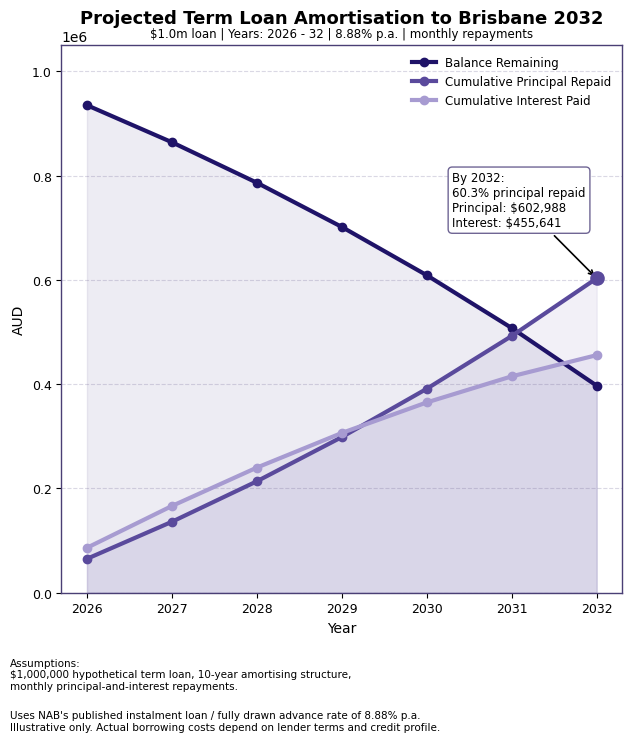

Monthly repayment: $12,602.73
Balance remaining in 2032: $397,012.34
Cumulative principal repaid by 2032: $602,987.66
Cumulative interest paid by 2032: $455,641.25
Percentage of principal repaid by 2032: 60.30%


In [40]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ----------------------------
# assumptions
# ----------------------------
loan_amount = 1_000_000          # hypothetical term loan
annual_rate = 0.0888             # NAB instalment loan / fully drawn advance rate
loan_term_years = 10             # 10-year term
start_year = 2026
end_year = 2032

# ----------------------------
# loan maths
# ----------------------------
monthly_rate = annual_rate / 12
n_payments = loan_term_years * 12

monthly_payment = loan_amount * (
    monthly_rate * (1 + monthly_rate) ** n_payments
) / (
    (1 + monthly_rate) ** n_payments - 1
)

balance = loan_amount
rows = []

for month in range(1, n_payments + 1):
    interest = balance * monthly_rate
    principal = monthly_payment - interest
    balance -= principal

    if balance < 0:
        principal += balance
        balance = 0

    rows.append({
        "month": month,
        "year": start_year + (month - 1) // 12,
        "interest_paid": interest,
        "principal_paid": principal,
        "balance_remaining": balance
    })

schedule = pd.DataFrame(rows)

annual = schedule[schedule["year"] <= end_year].groupby("year", as_index=False).agg({
    "interest_paid": "sum",
    "principal_paid": "sum",
    "balance_remaining": "last"
})

annual["cumulative_interest"] = annual["interest_paid"].cumsum()
annual["cumulative_principal"] = annual["principal_paid"].cumsum()

# 2032 summary
bal_2032 = annual.loc[annual["year"] == end_year, "balance_remaining"].iloc[0]
principal_2032 = annual.loc[annual["year"] == end_year, "cumulative_principal"].iloc[0]
interest_2032 = annual.loc[annual["year"] == end_year, "cumulative_interest"].iloc[0]
pct_principal_repaid = principal_2032 / loan_amount * 100

# ----------------------------
# plot
# ----------------------------
fig, ax = plt.subplots(figsize=(6.4, 8.2))

# white background
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# purple palette
balance_color = "#1f1368"      # dark purple
principal_color = "#5a4a9c"    # medium purple
interest_color = "#a79bd1"     # light purple

# lines
ax.plot(
    annual["year"], annual["balance_remaining"],
    marker="o", linewidth=3, color=balance_color,
    label="Balance Remaining"
)

ax.plot(
    annual["year"], annual["cumulative_principal"],
    marker="o", linewidth=3, color=principal_color,
    label="Cumulative Principal Repaid"
)

ax.plot(
    annual["year"], annual["cumulative_interest"],
    marker="o", linewidth=3, color=interest_color,
    label="Cumulative Interest Paid"
)

# subtle fills
ax.fill_between(
    annual["year"], annual["balance_remaining"],
    color=balance_color, alpha=0.08
)
ax.fill_between(
    annual["year"], annual["cumulative_principal"],
    color=principal_color, alpha=0.08
)
ax.fill_between(
    annual["year"], annual["cumulative_interest"],
    color=interest_color, alpha=0.12
)

# annotation at 2032
ax.scatter(end_year, principal_2032, s=90, color=principal_color, zorder=4)
ax.annotate(
    f"By 2032:\n"
    f"{pct_principal_repaid:.1f}% principal repaid\n"
    f"Principal: ${principal_2032:,.0f}\n"
    f"Interest: ${interest_2032:,.0f}",
    xy=(end_year, principal_2032),
    xytext=(2030.3, principal_2032 + 100000),
    arrowprops=dict(arrowstyle="->", color="black", lw=1.2),
    fontsize=8.5,
    bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="#6f6594")
)

# title + subtitle
ax.set_title(
    "Projected Term Loan Amortisation to Brisbane 2032",
    fontsize=13,
    fontweight="bold",
    pad=16
)

ax.text(
    0.5,
    1.01,
    "$1.0m loan | Years: 2026 - 32 | 8.88% p.a. | monthly repayments",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=8.5
)

# axes
ax.set_xlabel("Year", fontsize=10)
ax.set_ylabel("AUD", fontsize=10)
ax.set_xticks(annual["year"])
ax.set_ylim(0, max(loan_amount * 1.05, principal_2032 + 280000))

# purple grid / borders
ax.grid(axis="y", linestyle="--", alpha=0.25, color="#6f6594")
for spine in ax.spines.values():
    spine.set_color("#4a3f75")
    spine.set_linewidth(1.0)

ax.tick_params(axis="both", labelsize=9, colors="black")

# legend
ax.legend(frameon=False, fontsize=8.5, loc="upper right")

# footnotes
footnote_1 = (
    "Assumptions:\n"
    "$1,000,000 hypothetical term loan, 10-year amortising structure,\n"
    "monthly principal-and-interest repayments."
)

footnote_2 = (
    "Uses NAB's published instalment loan / fully drawn advance rate of 8.88% p.a.\n"
    "Illustrative only. Actual borrowing costs depend on lender terms and credit profile."
)

fig.text(0.02, 0.07, footnote_1, ha="left", va="bottom", fontsize=7.5, color="black")
fig.text(0.02, 0.02, footnote_2, ha="left", va="bottom", fontsize=7.5, color="black")

plt.tight_layout(rect=[0, 0.12, 1, 0.92])

plt.savefig("david_term_loan_brisbane_2032_purple.png", dpi=300, bbox_inches="tight")
plt.show()

# optional printed summary
print(f"Monthly repayment: ${monthly_payment:,.2f}")
print(f"Balance remaining in {end_year}: ${bal_2032:,.2f}")
print(f"Cumulative principal repaid by {end_year}: ${principal_2032:,.2f}")
print(f"Cumulative interest paid by {end_year}: ${interest_2032:,.2f}")
print(f"Percentage of principal repaid by {end_year}: {pct_principal_repaid:.2f}%")

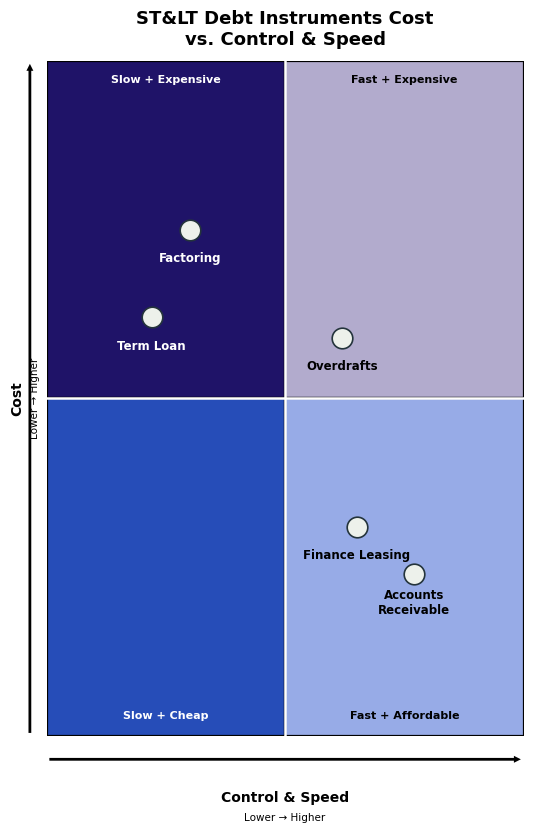

In [41]:
import matplotlib.pyplot as plt

# ----------------------------
# data
# x = control & speed
# y = cost
# ----------------------------
labels = [
    "Factoring",
    "Term Loan",
    "Overdrafts",
    "Finance Leasing",
    "Accounts\nReceivable"
]

x = [3.0, 2.2, 6.2, 6.5, 7.7]
y = [7.5, 6.2, 5.9, 3.1, 2.4]

# ----------------------------
# figure
# ----------------------------
fig, ax = plt.subplots(figsize=(5.4, 8.4))

fig.patch.set_facecolor("white")
ax.set_facecolor("white")

ax.set_xlim(0, 10)
ax.set_ylim(0, 10)

# remove default spines/ticks
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks([])
ax.set_yticks([])

# ----------------------------
# quadrant backgrounds
# ----------------------------
ax.add_patch(plt.Rectangle((0, 5), 5, 5, facecolor="#1f1368", edgecolor="black", linewidth=1.6))
ax.add_patch(plt.Rectangle((5, 5), 5, 5, facecolor="#b2abcd", edgecolor="black", linewidth=1.6))
ax.add_patch(plt.Rectangle((0, 0), 5, 5, facecolor="#264db8", edgecolor="black", linewidth=1.6))
ax.add_patch(plt.Rectangle((5, 0), 5, 5, facecolor="#97abe7", edgecolor="black", linewidth=1.6))

# divider lines
ax.plot([5, 5], [0, 10], color="white", linewidth=1.8)
ax.plot([0, 10], [5, 5], color="white", linewidth=1.8)

# ----------------------------
# scatter points
# ----------------------------
ax.scatter(
    x, y,
    s=220,
    facecolor="#edf1eb",
    edgecolor="#24343c",
    linewidth=1.2,
    zorder=3
)

# point labels
for xi, yi, label in zip(x, y, labels):
    txt_color = "white" if (yi > 5 and xi < 5) else "black"
    ax.text(
        xi,
        yi - 0.42,
        label,
        ha="center",
        va="center",
        fontsize=8.5,
        fontweight="semibold",
        color=txt_color
    )

# ----------------------------
# title
# ----------------------------
ax.set_title(
    "ST&LT Debt Instruments Cost\nvs. Control & Speed",
    fontsize=13,
    fontweight="bold",
    pad=12,
    color="black"
)

# quadrant labels
ax.text(
    2.5, 9.72, "Slow + Expensive",
    ha="center", va="center",
    fontsize=8, fontweight="bold", color="white"
)
ax.text(
    7.5, 9.72, "Fast + Expensive",
    ha="center", va="center",
    fontsize=8, fontweight="bold", color="black"
)
ax.text(
    2.5, 0.30, "Slow + Cheap",
    ha="center", va="center",
    fontsize=8, fontweight="bold", color="white"
)
ax.text(
    7.5, 0.30, "Fast + Affordable",
    ha="center", va="center",
    fontsize=8, fontweight="bold", color="black"
)

# ----------------------------
# custom axis arrows
# ----------------------------
ax.annotate(
    "", xy=(10, -0.35), xytext=(0, -0.35),
    arrowprops=dict(arrowstyle="simple", color="black", lw=0),
    annotation_clip=False
)

ax.annotate(
    "", xy=(-0.35, 10), xytext=(-0.35, 0),
    arrowprops=dict(arrowstyle="simple", color="black", lw=0),
    annotation_clip=False
)

# axis labels
ax.text(
    5, -0.92, "Control & Speed",
    ha="center", va="center",
    fontsize=10, fontweight="bold", color="black"
)
ax.text(
    5, -1.22, "Lower → Higher",
    ha="center", va="center",
    fontsize=7.5, color="black"
)

ax.text(
    -0.62, 5, "Cost",
    ha="center", va="center",
    rotation=90,
    fontsize=10, fontweight="bold", color="black"
)
ax.text(
    -0.25, 5, "Lower → Higher",
    ha="center", va="center",
    rotation=90,
    fontsize=7.5, color="black"
)

plt.tight_layout()
plt.savefig("narrow_quadrant_chart_matching_other_plots.png", dpi=300, bbox_inches="tight")
plt.show()

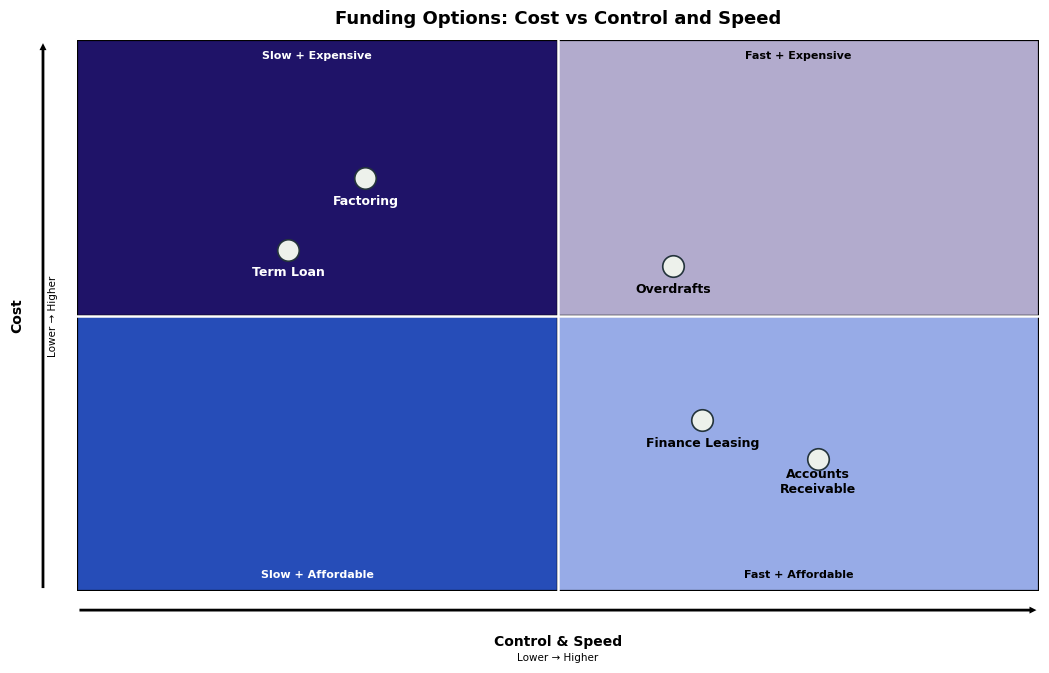

In [42]:
import matplotlib.pyplot as plt

# ----------------------------
# data
# x = control & speed
# y = cost
# ----------------------------
labels = [
    "Factoring",
    "Term Loan",
    "Overdrafts",
    "Finance Leasing",
    "Accounts\nReceivable"
]

x = [3.0, 2.2, 6.2, 6.5, 7.7]
y = [7.5, 6.2, 5.9, 3.1, 2.4]

# ----------------------------
# figure
# ----------------------------
fig, ax = plt.subplots(figsize=(10.5, 6.8))

fig.patch.set_facecolor("white")
ax.set_facecolor("white")

ax.set_xlim(0, 10)
ax.set_ylim(0, 10)

# remove default spines/ticks
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks([])
ax.set_yticks([])

# ----------------------------
# quadrant backgrounds
# ----------------------------
ax.add_patch(plt.Rectangle((0, 5), 5, 5, facecolor="#1f1368", edgecolor="black", linewidth=1.6))
ax.add_patch(plt.Rectangle((5, 5), 5, 5, facecolor="#b2abcd", edgecolor="black", linewidth=1.6))
ax.add_patch(plt.Rectangle((0, 0), 5, 5, facecolor="#264db8", edgecolor="black", linewidth=1.6))
ax.add_patch(plt.Rectangle((5, 0), 5, 5, facecolor="#97abe7", edgecolor="black", linewidth=1.6))

# divider lines
ax.plot([5, 5], [0, 10], color="white", linewidth=1.8)
ax.plot([0, 10], [5, 5], color="white", linewidth=1.8)

# ----------------------------
# scatter points
# ----------------------------
ax.scatter(
    x, y,
    s=240,
    facecolor="#edf1eb",
    edgecolor="#24343c",
    linewidth=1.2,
    zorder=3
)

# point labels
for xi, yi, label in zip(x, y, labels):
    txt_color = "white" if (yi > 5 and xi < 5) else "black"
    ax.text(
        xi,
        yi - 0.42,
        label,
        ha="center",
        va="center",
        fontsize=9,
        fontweight="semibold",
        color=txt_color
    )

# ----------------------------
# title
# ----------------------------
ax.set_title(
    "Funding Options: Cost vs Control and Speed",
    fontsize=13,
    fontweight="bold",
    pad=12,
    color="black"
)

# quadrant labels
ax.text(2.5, 9.72, "Slow + Expensive", ha="center", va="center",
        fontsize=8, fontweight="bold", color="white")
ax.text(7.5, 9.72, "Fast + Expensive", ha="center", va="center",
        fontsize=8, fontweight="bold", color="black")
ax.text(2.5, 0.30, "Slow + Affordable", ha="center", va="center",
        fontsize=8, fontweight="bold", color="white")
ax.text(7.5, 0.30, "Fast + Affordable", ha="center", va="center",
        fontsize=8, fontweight="bold", color="black")

# ----------------------------
# custom axis arrows
# ----------------------------
ax.annotate(
    "", xy=(10, -0.35), xytext=(0, -0.35),
    arrowprops=dict(arrowstyle="simple", color="black", lw=0),
    annotation_clip=False
)

ax.annotate(
    "", xy=(-0.35, 10), xytext=(-0.35, 0),
    arrowprops=dict(arrowstyle="simple", color="black", lw=0),
    annotation_clip=False
)

# axis labels
ax.text(
    5, -0.92, "Control & Speed",
    ha="center", va="center",
    fontsize=10, fontweight="bold", color="black"
)
ax.text(
    5, -1.22, "Lower → Higher",
    ha="center", va="center",
    fontsize=7.5, color="black"
)

ax.text(
    -0.62, 5, "Cost",
    ha="center", va="center",
    rotation=90,
    fontsize=10, fontweight="bold", color="black"
)
ax.text(
    -0.25, 5, "Lower → Higher",
    ha="center", va="center",
    rotation=90,
    fontsize=7.5, color="black"
)

plt.tight_layout()
plt.savefig("wide_funding_options_quadrant.png", dpi=300, bbox_inches="tight")
plt.show()

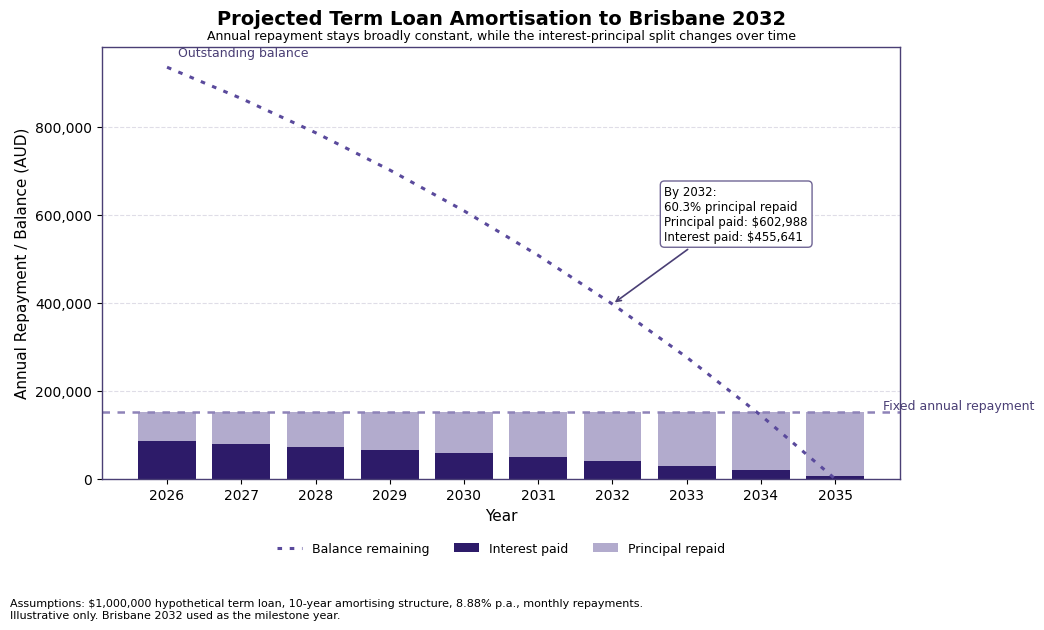

In [43]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import StrMethodFormatter

# ----------------------------
# assumptions
# ----------------------------
loan_amount = 1_000_000
annual_rate = 0.0888          # 8.88% p.a.
loan_term_years = 10
start_year = 2026

# ----------------------------
# loan maths
# ----------------------------
monthly_rate = annual_rate / 12
n_payments = loan_term_years * 12

monthly_payment = loan_amount * (
    monthly_rate * (1 + monthly_rate) ** n_payments
) / (
    (1 + monthly_rate) ** n_payments - 1
)

balance = loan_amount
rows = []

for month in range(1, n_payments + 1):
    interest = balance * monthly_rate
    principal = monthly_payment - interest
    balance -= principal

    if balance < 0:
        principal += balance
        balance = 0

    rows.append({
        "month": month,
        "year": start_year + (month - 1) // 12,
        "interest_paid": interest,
        "principal_paid": principal,
        "balance_remaining": balance
    })

schedule = pd.DataFrame(rows)

annual = schedule.groupby("year", as_index=False).agg({
    "interest_paid": "sum",
    "principal_paid": "sum",
    "balance_remaining": "last"
})

annual["total_paid"] = annual["interest_paid"] + annual["principal_paid"]

# ----------------------------
# colours
# ----------------------------
principal_color = "#b2abcd"   # light purple
interest_color = "#2d1b69"    # dark purple
balance_color = "#5a4a9c"     # medium purple
repayment_color = "#8e83b8"   # muted purple

# ----------------------------
# figure
# ----------------------------
fig, ax = plt.subplots(figsize=(10.5, 6.8))

fig.patch.set_facecolor("white")
ax.set_facecolor("white")

x = np.arange(len(annual))
years = annual["year"].astype(str)

# ----------------------------
# stacked bars
# ----------------------------
ax.bar(
    x,
    annual["interest_paid"],
    color=interest_color,
    width=0.78,
    label="Interest paid"
)

ax.bar(
    x,
    annual["principal_paid"],
    bottom=annual["interest_paid"],
    color=principal_color,
    width=0.78,
    label="Principal repaid"
)

# ----------------------------
# fixed repayment line
# ----------------------------
annual_payment = annual["total_paid"].iloc[0]

ax.axhline(
    annual_payment,
    color=repayment_color,
    linestyle=(0, (3, 3)),
    linewidth=1.8
)

ax.text(
    len(x) - 0.35,
    annual_payment + 14000,
    "Fixed annual repayment",
    ha="left",
    va="center",
    fontsize=9,
    color="#4a3f75"
)

# ----------------------------
# outstanding balance line
# ----------------------------
ax.plot(
    x,
    annual["balance_remaining"],
    color=balance_color,
    linestyle=(0, (1.5, 2.5)),
    linewidth=2.2,
    label="Balance remaining"
)

ax.text(
    0.15,
    annual["balance_remaining"].iloc[0] + 25000,
    "Outstanding balance",
    fontsize=9,
    color="#4a3f75"
)

# ----------------------------
# titles
# ----------------------------
ax.set_title(
    "Projected Term Loan Amortisation to Brisbane 2032",
    fontsize=14,
    fontweight="bold",
    pad=16
)

ax.text(
    0.5,
    1.01,
    "Annual repayment stays broadly constant, while the interest-principal split changes over time",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=9
)

# ----------------------------
# axes
# ----------------------------
ax.set_xticks(x)
ax.set_xticklabels(years, fontsize=10)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Annual Repayment / Balance (AUD)", fontsize=11)

ax.ticklabel_format(style="plain", axis="y")
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

ax.grid(axis="y", linestyle="--", alpha=0.22, color="#6f6594")

for spine in ax.spines.values():
    spine.set_color("#4a3f75")
    spine.set_linewidth(1.0)

# ----------------------------
# annotation for 2032
# ----------------------------
idx_2032 = annual.index[annual["year"] == 2032][0]
principal_to_2032 = annual.loc[annual["year"] <= 2032, "principal_paid"].sum()
interest_to_2032 = annual.loc[annual["year"] <= 2032, "interest_paid"].sum()
pct_principal = principal_to_2032 / loan_amount * 100

ax.annotate(
    f"By 2032:\n{pct_principal:.1f}% principal repaid\n"
    f"Principal paid: ${principal_to_2032:,.0f}\n"
    f"Interest paid: ${interest_to_2032:,.0f}",
    xy=(idx_2032, annual.loc[idx_2032, "balance_remaining"]),
    xytext=(idx_2032 + 0.7, annual["balance_remaining"].max() * 0.58),
    arrowprops=dict(arrowstyle="->", color="#4a3f75", lw=1.2),
    fontsize=8.5,
    bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="#6f6594")
)

# ----------------------------
# legend
# ----------------------------
ax.legend(frameon=False, fontsize=9, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3)

# ----------------------------
# footnotes
# ----------------------------
fig.text(
    0.01, 0.02,
    "Assumptions: $1,000,000 hypothetical term loan, 10-year amortising structure, 8.88% p.a., monthly repayments.\n"
    "Illustrative only. Brisbane 2032 used as the milestone year.",
    ha="left", va="bottom", fontsize=8
)

plt.tight_layout(rect=[0, 0.07, 1, 0.94])
plt.savefig("term_loan_amortisation_purple_style.png", dpi=300, bbox_inches="tight")
plt.show()

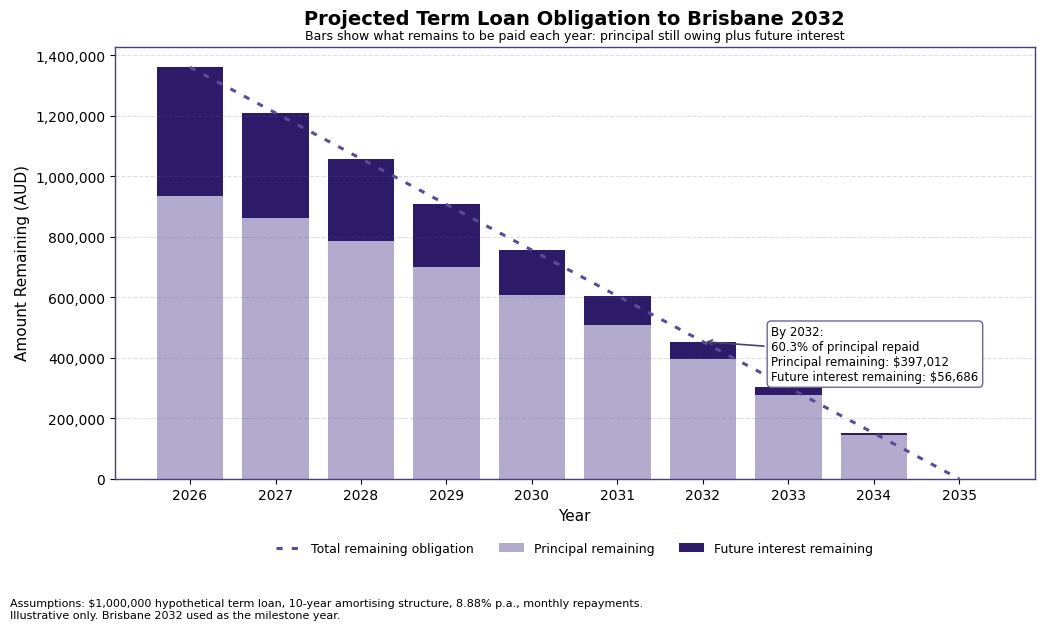

In [44]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import StrMethodFormatter

# ----------------------------
# assumptions
# ----------------------------
loan_amount = 1_000_000
annual_rate = 0.0888          # 8.88% p.a.
loan_term_years = 10
start_year = 2026
milestone_year = 2032

# ----------------------------
# loan maths
# ----------------------------
monthly_rate = annual_rate / 12
n_payments = loan_term_years * 12

monthly_payment = loan_amount * (
    monthly_rate * (1 + monthly_rate) ** n_payments
) / (
    (1 + monthly_rate) ** n_payments - 1
)

balance = loan_amount
rows = []

for month in range(1, n_payments + 1):
    interest = balance * monthly_rate
    principal = monthly_payment - interest
    balance -= principal

    if balance < 0:
        principal += balance
        balance = 0

    rows.append({
        "month": month,
        "year": start_year + (month - 1) // 12,
        "interest_paid": interest,
        "principal_paid": principal,
        "balance_remaining": balance
    })

schedule = pd.DataFrame(rows)

# yearly snapshot = last month of each year
year_end = schedule.groupby("year", as_index=False).last()

# future interest remaining from each year-end onward
future_interest_remaining = []
for yr in year_end["year"]:
    remaining_interest = schedule.loc[schedule["year"] > yr, "interest_paid"].sum()
    future_interest_remaining.append(remaining_interest)

year_end["future_interest_remaining"] = future_interest_remaining
year_end["principal_remaining"] = year_end["balance_remaining"]
year_end["total_remaining_obligation"] = (
    year_end["principal_remaining"] + year_end["future_interest_remaining"]
)

# milestone values
row_2032 = year_end.loc[year_end["year"] == milestone_year].iloc[0]
principal_remaining_2032 = row_2032["principal_remaining"]
interest_remaining_2032 = row_2032["future_interest_remaining"]
principal_repaid_2032 = loan_amount - principal_remaining_2032
pct_principal_repaid = principal_repaid_2032 / loan_amount * 100

# ----------------------------
# colours
# ----------------------------
principal_color = "#b2abcd"   # light purple
interest_color = "#2d1b69"    # dark purple
line_color = "#5a4a9c"        # medium purple

# ----------------------------
# plot
# ----------------------------
fig, ax = plt.subplots(figsize=(10.5, 6.8))

fig.patch.set_facecolor("white")
ax.set_facecolor("white")

x = np.arange(len(year_end))
years = year_end["year"].astype(str)

# stacked bars: remaining obligation split into principal + future interest
ax.bar(
    x,
    year_end["principal_remaining"],
    color=principal_color,
    width=0.78,
    label="Principal remaining"
)

ax.bar(
    x,
    year_end["future_interest_remaining"],
    bottom=year_end["principal_remaining"],
    color=interest_color,
    width=0.78,
    label="Future interest remaining"
)

# dotted line for total remaining obligation
ax.plot(
    x,
    year_end["total_remaining_obligation"],
    color=line_color,
    linestyle=(0, (2, 3)),
    linewidth=2.2,
    label="Total remaining obligation"
)

# title + subtitle
ax.set_title(
    "Projected Term Loan Obligation to Brisbane 2032",
    fontsize=14,
    fontweight="bold",
    pad=16
)

ax.text(
    0.5,
    1.01,
    "Bars show what remains to be paid each year: principal still owing plus future interest",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=9
)

# axes
ax.set_xticks(x)
ax.set_xticklabels(years, fontsize=10)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Amount Remaining (AUD)", fontsize=11)

ax.ticklabel_format(style="plain", axis="y")
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

ax.grid(axis="y", linestyle="--", alpha=0.22, color="#6f6594")
for spine in ax.spines.values():
    spine.set_color("#4a3f75")
    spine.set_linewidth(1.0)

# annotation for 2032
idx_2032 = year_end.index[year_end["year"] == milestone_year][0]

ax.annotate(
    f"By 2032:\n"
    f"{pct_principal_repaid:.1f}% of principal repaid\n"
    f"Principal remaining: ${principal_remaining_2032:,.0f}\n"
    f"Future interest remaining: ${interest_remaining_2032:,.0f}",
    xy=(idx_2032, row_2032["total_remaining_obligation"]),
    xytext=(idx_2032 + 0.8, row_2032["total_remaining_obligation"] * 0.72),
    arrowprops=dict(arrowstyle="->", color="#4a3f75", lw=1.2),
    fontsize=8.5,
    bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="#6f6594")
)

# legend
ax.legend(frameon=False, fontsize=9, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3)

# footnotes
fig.text(
    0.01, 0.02,
    "Assumptions: $1,000,000 hypothetical term loan, 10-year amortising structure, 8.88% p.a., monthly repayments.\n"
    "Illustrative only. Brisbane 2032 used as the milestone year.",
    ha="left", va="bottom", fontsize=8
)

plt.tight_layout(rect=[0, 0.07, 1, 0.94])
plt.savefig("term_loan_remaining_obligation_purple.png", dpi=300, bbox_inches="tight")
plt.show()

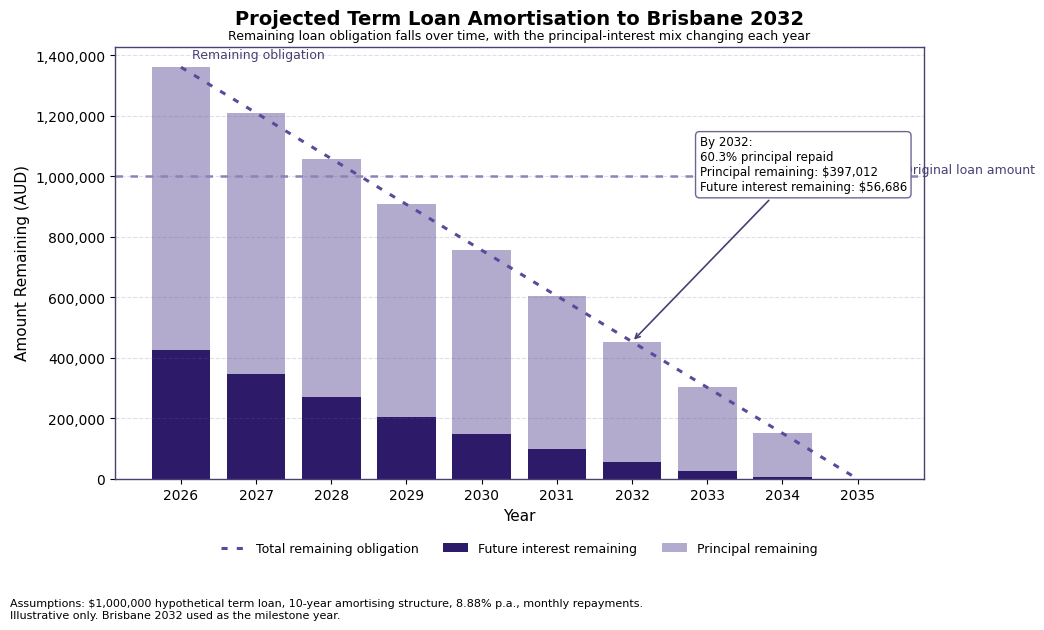

In [47]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import StrMethodFormatter

# ----------------------------
# assumptions
# ----------------------------
loan_amount = 1_000_000
annual_rate = 0.0888
loan_term_years = 10
start_year = 2026
target_year = 2032

# ----------------------------
# loan maths
# ----------------------------
monthly_rate = annual_rate / 12
n_payments = loan_term_years * 12

monthly_payment = loan_amount * (
    monthly_rate * (1 + monthly_rate) ** n_payments
) / (
    (1 + monthly_rate) ** n_payments - 1
)

balance = loan_amount
rows = []

for month in range(1, n_payments + 1):
    year = start_year + (month - 1) // 12

    interest = balance * monthly_rate
    principal = monthly_payment - interest
    balance -= principal

    if balance < 0:
        principal += balance
        balance = 0

    rows.append({
        "month": month,
        "year": year,
        "interest_paid": interest,
        "principal_paid": principal,
        "balance_remaining": balance
    })

schedule = pd.DataFrame(rows)

# year-end snapshots
year_end = schedule.groupby("year", as_index=False).last()

# future interest still left to pay from each year-end onward
future_interest_remaining = []
for yr in year_end["year"]:
    remaining_interest = schedule.loc[schedule["year"] > yr, "interest_paid"].sum()
    future_interest_remaining.append(remaining_interest)

year_end["future_interest_remaining"] = future_interest_remaining
year_end["principal_remaining"] = year_end["balance_remaining"]
year_end["total_remaining_obligation"] = (
    year_end["principal_remaining"] + year_end["future_interest_remaining"]
)

# 2032 summary
row_2032 = year_end.loc[year_end["year"] == target_year].iloc[0]
principal_remaining_2032 = row_2032["principal_remaining"]
interest_remaining_2032 = row_2032["future_interest_remaining"]
principal_repaid_2032 = loan_amount - principal_remaining_2032
pct_principal_repaid = principal_repaid_2032 / loan_amount * 100

# ----------------------------
# colours
# ----------------------------
principal_color = "#b2abcd"   # light purple
interest_color = "#2d1b69"    # dark purple
line_color = "#5a4a9c"        # medium purple
reference_color = "#8e83b8"   # muted purple

# ----------------------------
# plot
# ----------------------------
fig, ax = plt.subplots(figsize=(10.5, 6.8))

fig.patch.set_facecolor("white")
ax.set_facecolor("white")

x = np.arange(len(year_end))
years = year_end["year"].astype(str)

# stacked bars
ax.bar(
    x,
    year_end["future_interest_remaining"],
    color=interest_color,
    width=0.78,
    label="Future interest remaining"
)

ax.bar(
    x,
    year_end["principal_remaining"],
    bottom=year_end["future_interest_remaining"],
    color=principal_color,
    width=0.78,
    label="Principal remaining"
)

# dotted line for total remaining obligation
ax.plot(
    x,
    year_end["total_remaining_obligation"],
    color=line_color,
    linestyle=(0, (2, 3)),
    linewidth=2.2,
    label="Total remaining obligation"
)

# dashed reference line
ax.axhline(
    loan_amount,
    color=reference_color,
    linestyle=(0, (3, 3)),
    linewidth=1.8
)

ax.text(
    len(x) - 0.4,
    loan_amount + 20000,
    "Original loan amount",
    ha="left",
    va="center",
    fontsize=9,
    color="#4a3f75"
)

ax.text(
    0.15,
    year_end["total_remaining_obligation"].iloc[0] + 30000,
    "Remaining obligation",
    fontsize=9,
    color="#4a3f75"
)

# ----------------------------
# title
# ----------------------------
ax.set_title(
    "Projected Term Loan Amortisation to Brisbane 2032",
    fontsize=14,
    fontweight="bold",
    pad=16
)

ax.text(
    0.5,
    1.01,
    "Remaining loan obligation falls over time, with the principal-interest mix changing each year",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=9
)

# ----------------------------
# axes
# ----------------------------
ax.set_xticks(x)
ax.set_xticklabels(years, fontsize=10)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Amount Remaining (AUD)", fontsize=11)

ax.ticklabel_format(style="plain", axis="y")
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

ax.grid(axis="y", linestyle="--", alpha=0.22, color="#6f6594")

for spine in ax.spines.values():
    spine.set_color("#4a3f75")
    spine.set_linewidth(1.0)

# ----------------------------
# annotation for 2032
# ----------------------------
idx_2032 = year_end.index[year_end["year"] == target_year][0]

ax.annotate(
    f"By 2032:\n"
    f"{pct_principal_repaid:.1f}% principal repaid\n"
    f"Principal remaining: ${principal_remaining_2032:,.0f}\n"
    f"Future interest remaining: ${interest_remaining_2032:,.0f}",
    xy=(idx_2032, year_end.loc[idx_2032, "total_remaining_obligation"]),
    xytext=(idx_2032 + 0.9, year_end["total_remaining_obligation"].max() * 0.70),
    arrowprops=dict(arrowstyle="->", color="#4a3f75", lw=1.2),
    fontsize=8.5,
    bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="#6f6594")
)

# ----------------------------
# legend
# ----------------------------
ax.legend(frameon=False, fontsize=9, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3)

# ----------------------------
# footnotes
# ----------------------------
fig.text(
    0.01, 0.02,
    "Assumptions: $1,000,000 hypothetical term loan, 10-year amortising structure, 8.88% p.a., monthly repayments.\n"
    "Illustrative only. Brisbane 2032 used as the milestone year.",
    ha="left", va="bottom", fontsize=8
)

plt.tight_layout(rect=[0, 0.07, 1, 0.94])
plt.savefig("term_loan_amortisation_purple_style.png", dpi=300, bbox_inches="tight")
plt.show()

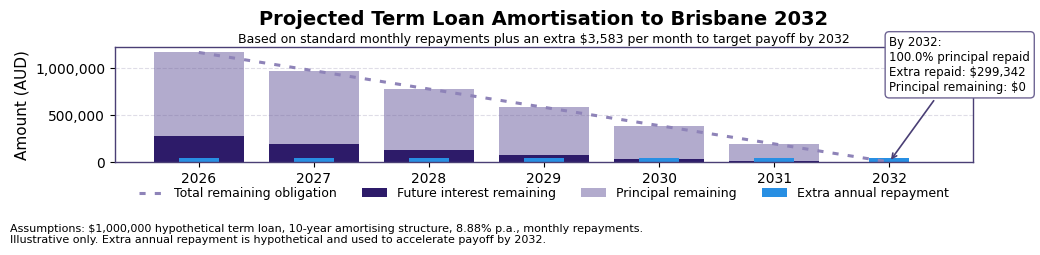

In [66]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import StrMethodFormatter

# ----------------------------
# assumptions
# ----------------------------
loan_amount = 1_000_000
annual_rate = 0.0888
loan_term_years = 10
start_year = 2026
target_year = 2032
extra_annual_repayment = 43000   # change this if needed

# ----------------------------
# loan maths
# ----------------------------
monthly_rate = annual_rate / 12
n_payments = loan_term_years * 12

monthly_payment = loan_amount * (
    monthly_rate * (1 + monthly_rate) ** n_payments
) / (
    (1 + monthly_rate) ** n_payments - 1
)

balance = loan_amount
rows = []

for month in range(1, n_payments + 1):
    year = start_year + (month - 1) // 12
    month_in_year = ((month - 1) % 12) + 1

    if balance <= 0:
        break

    interest = balance * monthly_rate
    principal = monthly_payment - interest
    balance -= principal

    extra_payment = 0

    # extra repayment in December up to target year
    if month_in_year == 12 and year <= target_year and balance > 0:
        extra_payment = min(extra_annual_repayment, balance)
        balance -= extra_payment

    if balance < 0:
        principal += balance
        balance = 0

    rows.append({
        "month": month,
        "year": year,
        "interest_paid": interest,
        "principal_paid": principal,
        "extra_payment": extra_payment,
        "balance_remaining": balance
    })

schedule = pd.DataFrame(rows)

# ----------------------------
# yearly summary
# ----------------------------
annual = schedule.groupby("year", as_index=False).agg({
    "interest_paid": "sum",
    "principal_paid": "sum",
    "extra_payment": "sum",
    "balance_remaining": "last"
})

# make sure all years to target_year exist
all_years = pd.DataFrame({"year": np.arange(start_year, target_year + 1)})
annual = all_years.merge(annual, on="year", how="left").fillna(0)

# forward-fill balance as 0 after payoff
annual["balance_remaining"] = annual["balance_remaining"].replace(0, np.nan)
annual["balance_remaining"] = annual["balance_remaining"].ffill()
annual.loc[annual["year"] > schedule["year"].max(), "balance_remaining"] = 0

# if loan paid off before target, force later years to zero
paid_off_year = schedule.loc[schedule["balance_remaining"] <= 0, "year"]
if not paid_off_year.empty:
    payoff_year = paid_off_year.iloc[0]
    annual.loc[annual["year"] >= payoff_year, "balance_remaining"] = 0

# future interest remaining from each year-end onward
future_interest_remaining = []
for yr in annual["year"]:
    remaining_interest = schedule.loc[schedule["year"] > yr, "interest_paid"].sum()
    future_interest_remaining.append(remaining_interest)

annual["future_interest_remaining"] = future_interest_remaining
annual["principal_remaining"] = annual["balance_remaining"]
annual["total_remaining_obligation"] = (
    annual["principal_remaining"] + annual["future_interest_remaining"]
)

# cumulative extra repayments for annotation
annual["cumulative_extra"] = annual["extra_payment"].cumsum()

# ----------------------------
# 2032 summary
# ----------------------------
row_target = annual.loc[annual["year"] == target_year].iloc[0]
principal_remaining_target = row_target["principal_remaining"]
interest_remaining_target = row_target["future_interest_remaining"]
principal_repaid_target = loan_amount - principal_remaining_target
pct_principal_repaid = principal_repaid_target / loan_amount * 100
extra_paid_target = annual.loc[annual["year"] <= target_year, "extra_payment"].sum()

# ----------------------------
# colours
# ----------------------------
principal_color = "#b2abcd"   # light purple
interest_color = "#2d1b69"    # dark purple
extra_color = "#288fe3"       # medium purple
line_color = "#8e83b8"        # muted purple

# ----------------------------
# plot
# ----------------------------
# fig, ax = plt.subplots(figsize=(10.5, 6.8))

fig, ax = plt.subplots(figsize=(10.5, 2.72))

fig.patch.set_facecolor("none")
ax.set_facecolor("none")

x = np.arange(len(annual))
years = annual["year"].astype(str)

# stacked bars
ax.bar(
    x,
    annual["future_interest_remaining"],
    color=interest_color,
    width=0.78,
    label="Future interest remaining"
)

ax.bar(
    x,
    annual["principal_remaining"],
    bottom=annual["future_interest_remaining"],
    color=principal_color,
    width=0.78,
    label="Principal remaining"
)

# extra repayments as separate overlay bars near bottom
ax.bar(
    x,
    annual["extra_payment"],
    color=extra_color,
    width=0.35,
    label="Extra annual repayment"
)

# dotted line
ax.plot(
    x,
    annual["total_remaining_obligation"],
    color=line_color,
    linestyle=(0, (2, 3)),
    linewidth=2.2,
    label="Total remaining obligation"
)

# title
ax.set_title(
    "Projected Term Loan Amortisation to Brisbane 2032",
    fontsize=14,
    fontweight="bold",
    pad=16
)

ax.text(
    0.5,
    1.01,
    f"Based on standard monthly repayments plus an extra ${extra_annual_repayment/12:,.0f} per month to target payoff by 2032",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=9
)

# axes
ax.set_xticks(x)
ax.set_xticklabels(years, fontsize=10)
ax.set_xlabel(" ", fontsize=11)
ax.set_ylabel("Amount (AUD)", fontsize=11)

ax.ticklabel_format(style="plain", axis="y")
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

ax.grid(axis="y", linestyle="--", alpha=0.22, color="#6f6594")
for spine in ax.spines.values():
    spine.set_color("#4a3f75")
    spine.set_linewidth(1.0)

# annotation
target_idx = annual.index[annual["year"] == target_year][0]
ax.annotate(
    f"By {target_year}:\n"
    f"{pct_principal_repaid:.1f}% principal repaid\n"
    f"Extra repaid: ${extra_paid_target:,.0f}\n"
    f"Principal remaining: ${principal_remaining_target:,.0f}",
    xy=(target_idx, annual.loc[target_idx, "total_remaining_obligation"]),
    xytext=(target_idx - 0.0, max(annual["total_remaining_obligation"]) * 0.65),
    arrowprops=dict(arrowstyle="->", color="#4a3f75", lw=1.2),
    fontsize=8.5,
    bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="#6f6594")
)

# legend
ax.legend(frameon=False, fontsize=9, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=4)

# footnote
fig.text(
    0.01, 0.02,
    "Assumptions: $1,000,000 hypothetical term loan, 10-year amortising structure, 8.88% p.a., monthly repayments.\n"
    "Illustrative only. Extra annual repayment is hypothetical and used to accelerate payoff by 2032.",
    ha="left", va="bottom", fontsize=8
)

plt.tight_layout(rect=[0, 0.07, 1, 0.94])
plt.savefig("term_loan_amortisation_extra_repayments_visible.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
ax.text(
    0.5,
    1.01,
    f"Based on standard monthly repayments plus an extra ${extra_annual_repayment/12:,.0f} per month to target payoff by 2032",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=9
)